<a href="https://colab.research.google.com/github/UXDynamicSolution/MineriaDatosDuocPAO/blob/main/uf_chile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🇨🇱 Exploración de Datos Económicos de Chile con Pandas

## 🧠 Aprendiendo Minería de Datos con Información del Mundo Real

✍️ **Autor del notebook:** _Carlos Muñoz Salgado_  
📅 **Fecha:** Abril 2025  
🔍 **Objetivo:** Enseñar análisis exploratorio de datos (EDA) con `pandas` y `matplotlib`, usando información económica real de Chile entre los años 2006 y 2023.

---

## 📌 Disclaimer

> Este análisis no tiene fines políticos.  
> Como analista de datos, me comprometo a mantener objetividad en el tratamiento, interpretación y visualización de los datos.  
> Todos los conjuntos de datos utilizados son públicos y han sido obtenidos de fuentes oficiales como el Banco Central, INE y la CMF.

---

## 🔍 ¿Qué aprenderás con este notebook?

- Cargar múltiples datasets con `pandas`
- Realizar limpieza básica y manejo de valores nulos
- Aplicar transformaciones de fechas y formatos monetarios
- Visualizar series temporales y comparaciones económicas con `matplotlib` y `seaborn`
- Calcular correlaciones entre indicadores como Deuda Pública, PIB, Tipo de Cambio, entre otros
- Identificar patrones, outliers y relaciones inesperadas

---

## 📊 Datasets utilizados

1. **Deuda pública y PIB** — Banco Central
2. **Tipo de cambio USD/CLP** — BCU
3. **Inversiones AFP** — CMF
4. **IPC (Índice de Precios al Consumidor)** — INE
5. **Tasa de desempleo trimestral** — INE

##  Dataframes Importados


- df = pd.read_excel('uf.xlsx')
- df_ipc = pd.read_excel('ipc_anual_mensual.xlsx')
- df_imacec = pd.read_excel("imacec.xls")
- df_desempleo = pd.read_excel("desempleo.xls")
- df_pib = pd.read_excel("pib.xls")
- df_deuda_publica_pib = pd.read_excel("deuda_publica_pib.xlsx")
---

## 🔧 Herramientas necesarias

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [ ]:
import sys
import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import style

## 💸 ¿Qué es la Unidad de Fomento (UF)?

La **Unidad de Fomento (UF)** es una unidad de cuenta reajustable por inflación, utilizada ampliamente en Chile para proteger el valor del dinero en contratos de largo plazo.

### 🎯 Objetivo Principal

- **Proteger** contratos financieros y obligaciones a largo plazo frente a la pérdida de valor del dinero causada por la inflación.
- **Estabilizar** la economía en un contexto de alta inflación, especialmente relevante en Chile durante las décadas de 1960 y 1970.

### 🕰️ Evolución del Reajuste

- **Originalmente**, la UF se reajustaba **mensualmente** en función de la inflación.
- **Actualmente**, su valor se **actualiza diariamente** con base en el **Índice de Precios al Consumidor (IPC)** publicado por el **Instituto Nacional de Estadísticas (INE)**.

> La UF se ha convertido en un pilar fundamental del sistema financiero chileno, utilizada en créditos hipotecarios, contratos de arriendo, seguros, inversiones y más.


In [ ]:
df = pd.read_excel('uf.xlsx')

In [ ]:
df.columns

Index(['fecha', 'valor_uf_dia'], dtype='object')

In [ ]:
df.head()

,fecha,valor_uf_dia
0,1977-08-01,389.10
1,1977-08-02,389.51
2,1977-08-03,389.91
3,1977-08-04,390.32
4,1977-08-05,390.73


In [ ]:
df.tail()

,fecha,valor_uf_dia
17414,2025-04-05,38919.16
17415,2025-04-06,38924.18
17416,2025-04-07,38929.19
17417,2025-04-08,38934.20
17418,2025-04-09,38939.22


In [ ]:
df.dtypes

,0
fecha,datetime64[ns]
valor_uf_dia,float64


In [ ]:
df['anio'] = df['fecha'].dt.year

In [ ]:
df

,fecha,valor_uf_dia,anio
0,1977-08-01,389.10,1977
1,1977-08-02,389.51,1977
2,1977-08-03,389.91,1977
3,1977-08-04,390.32,1977
4,1977-08-05,390.73,1977
...,...,...,...
17414,2025-04-05,38919.16,2025
17415,2025-04-06,38924.18,2025
17416,2025-04-07,38929.19,2025
17417,2025-04-08,38934.20,2025


In [ ]:
uf_por_anio = df.groupby('anio')['valor_uf_dia'].agg(['first', 'last'])

In [ ]:
uf_por_anio['crecimiento_%'] = ((uf_por_anio['last'] - uf_por_anio['first']) / uf_por_anio['first']) * 100

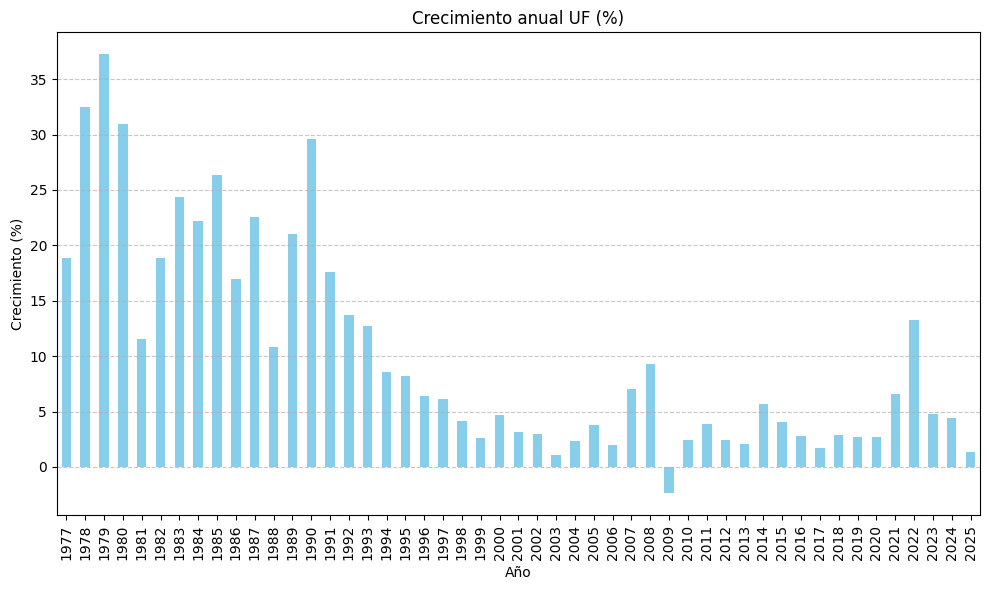

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
uf_por_anio['crecimiento_%'].plot(kind='bar', color='skyblue')
plt.title('Crecimiento anual UF (%)')
plt.xlabel('Año')
plt.ylabel('Crecimiento (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


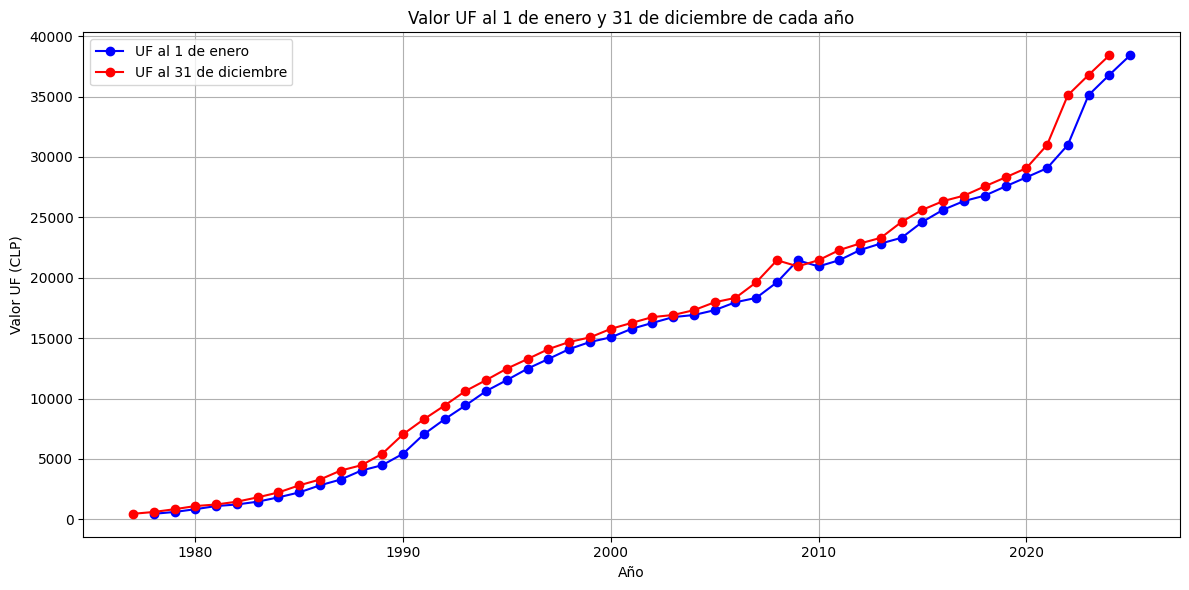

In [ ]:
import matplotlib.pyplot as plt

# Filtrar 1 de enero y 31 de diciembre
enero_1 = df[df['fecha'].dt.strftime('%m-%d') == '01-01'].copy()
dic_31 = df[df['fecha'].dt.strftime('%m-%d') == '12-31'].copy()

# Asegurarte de tener el año como columna
enero_1['anio'] = enero_1['fecha'].dt.year
dic_31['anio'] = dic_31['fecha'].dt.year

# Establecer año como índice
enero_1.set_index('anio', inplace=True)
dic_31.set_index('anio', inplace=True)

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(enero_1['valor_uf_dia'], marker='o', label='UF al 1 de enero', color='blue')
plt.plot(dic_31['valor_uf_dia'], marker='o', label='UF al 31 de diciembre', color='red')

# Estética del gráfico
plt.title('Valor UF al 1 de enero y 31 de diciembre de cada año')
plt.xlabel('Año')
plt.ylabel('Valor UF (CLP)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
correlation = df.corr()

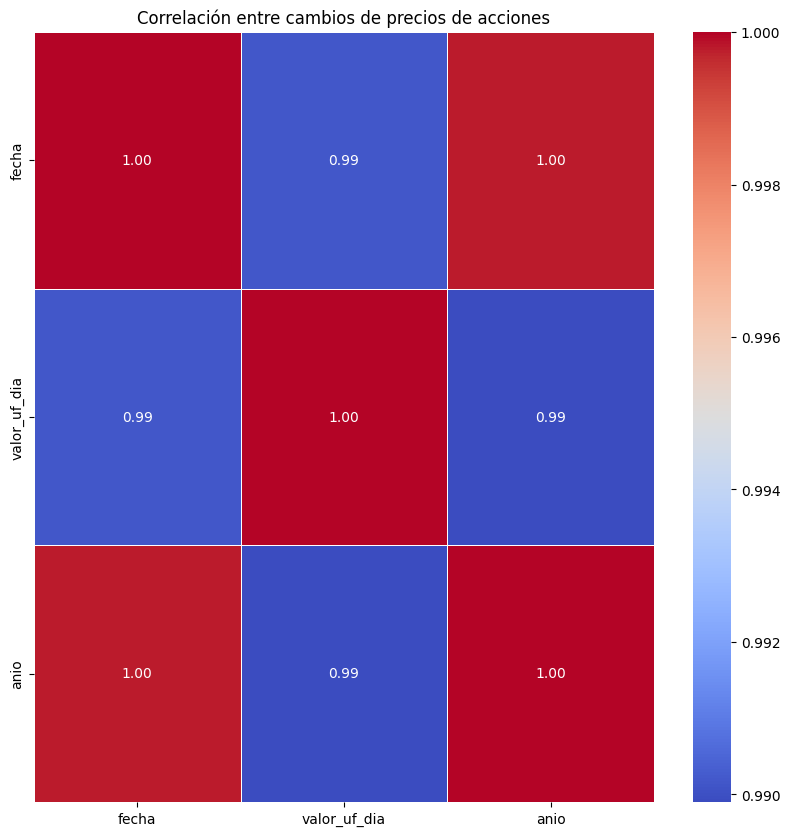

In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación entre cambios de precios de acciones")
plt.show()

## 📈 ¿Qué es el Índice de Precios al Consumidor (IPC)?

El **Índice de Precios al Consumidor (IPC)** es un indicador económico que refleja la evolución en el tiempo del **nivel de precios de una canasta de bienes y servicios representativa del consumo de los hogares**.

### 🛒 ¿Qué mide el IPC?

- Mide **cómo varían los precios** de productos y servicios consumidos habitualmente por los hogares chilenos.
- Permite estimar la **inflación** o la **deflación** en un período determinado.

### 🧮 ¿Cómo se calcula?

- Es calculado mensualmente por el **Instituto Nacional de Estadísticas (INE)**.
- Se basa en una **canasta de consumo representativa**, que incluye alimentos, transporte, salud, educación, vivienda, entre otros.
- Cada ítem tiene un **peso relativo**, de acuerdo con su importancia en el gasto promedio de los hogares.

### 🎯 ¿Para qué se utiliza?

- Es un **indicador clave de inflación** y se usa para tomar decisiones en **política monetaria**, **reajustar contratos**, **establecer salarios**, **actualizar pensiones**, entre otros.
- Sirve como base para **reajustar la UF** (Unidad de Fomento) diariamente.

> En resumen, el IPC es una herramienta fundamental para entender el comportamiento del costo de la vida en Chile.


In [ ]:
df_ipc = pd.read_excel('ipc_anual_mensual.xlsx')

In [ ]:
df_ipc

,fecha,mensual,anual
0,2011-01-01,0.3,2.7
1,2011-02-01,0.2,2.7
2,2011-03-01,0.8,3.4
3,2011-04-01,0.3,3.2
4,2011-05-01,0.4,3.3
...,...,...,...
165,2024-10-01,1.0,4.7
166,2024-11-01,0.2,4.2
167,2024-12-01,-0.2,4.5
168,2025-01-01,1.1,4.9


In [ ]:
df_ipc.dtypes

,0
fecha,datetime64[ns]
mensual,float64
anual,float64


In [ ]:
df_ipc.columns = df_ipc.columns.str.strip()  # Eliminar espacios innecesarios
df_ipc

,fecha,mensual,anual
0,2011-01-01,0.3,2.7
1,2011-02-01,0.2,2.7
2,2011-03-01,0.8,3.4
3,2011-04-01,0.3,3.2
4,2011-05-01,0.4,3.3
...,...,...,...
165,2024-10-01,1.0,4.7
166,2024-11-01,0.2,4.2
167,2024-12-01,-0.2,4.5
168,2025-01-01,1.1,4.9


In [ ]:
df_ipc.describe()

,fecha,mensual,anual
count,170,170.000000,170.000000
mean,2018-01-15 09:44:28.235294208,0.351176,4.238824
min,2011-01-01 00:00:00,-0.500000,0.900000
25%,2014-07-08 18:00:00,0.100000,2.700000
50%,2018-01-16 12:00:00,0.300000,3.450000
75%,2021-07-24 06:00:00,0.500000,4.675000
max,2025-02-01 00:00:00,1.900000,14.100000
std,NaN,0.382492,2.730091


In [ ]:
df_ipc.isnull().sum()

,0
fecha,0
mensual,0
anual,0


In [ ]:
df_ipc.dtypes

,0
fecha,datetime64[ns]
mensual,float64
anual,float64


In [ ]:
df_ipc['mensual']

,mensual
0,0.3
1,0.2
2,0.8
3,0.3
4,0.4
...,...
165,1.0
166,0.2
167,-0.2
168,1.1


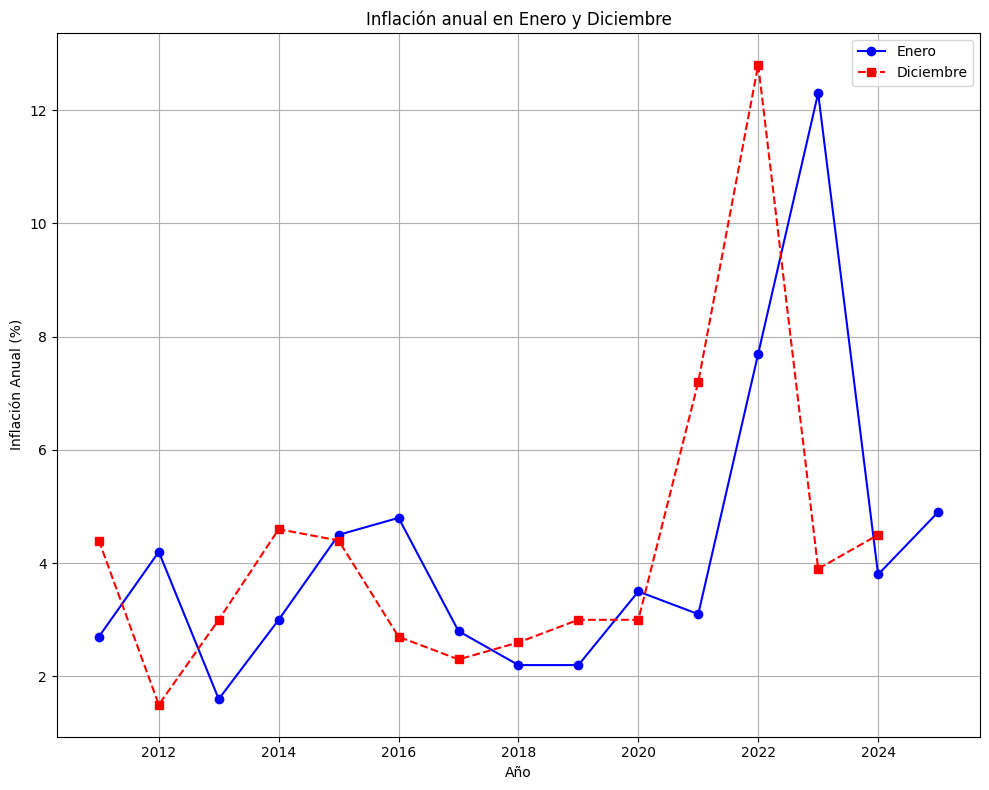

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegúrate de que 'fecha' esté en datetime
df_ipc['fecha'] = pd.to_datetime(df_ipc['fecha'])

# Extraer año y mes
df_ipc['anio'] = df_ipc['fecha'].dt.year
df_ipc['mes'] = df_ipc['fecha'].dt.month

# Ordenar por fecha para asegurar que el último valor del mes sea correcto
df_ipc = df_ipc.sort_values(by='fecha')

# Agrupar por año y mes, tomar último valor del mes
df_mensual = df_ipc.groupby(['anio', 'mes']).last().reset_index()

# Filtrar solo enero y diciembre
enero = df_mensual[df_mensual['mes'] == 1]
diciembre = df_mensual[df_mensual['mes'] == 12]

# Graficar
plt.figure(figsize=(10, 8))
plt.plot(enero['anio'], enero['anual'], marker='o', label='Enero', color='blue')
plt.plot(diciembre['anio'], diciembre['anual'], marker='s', label='Diciembre', linestyle='--', color='red')
plt.title('Inflación anual en Enero y Diciembre')
plt.xlabel('Año')
plt.ylabel('Inflación Anual (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Podemos ver el año 2022
## Link Noticia: https://www.df.cl/economia-y-politica/macro/chile-cierra-2022-con-la-mayor-inflacion-desde-1991-tras-un-ipc-en

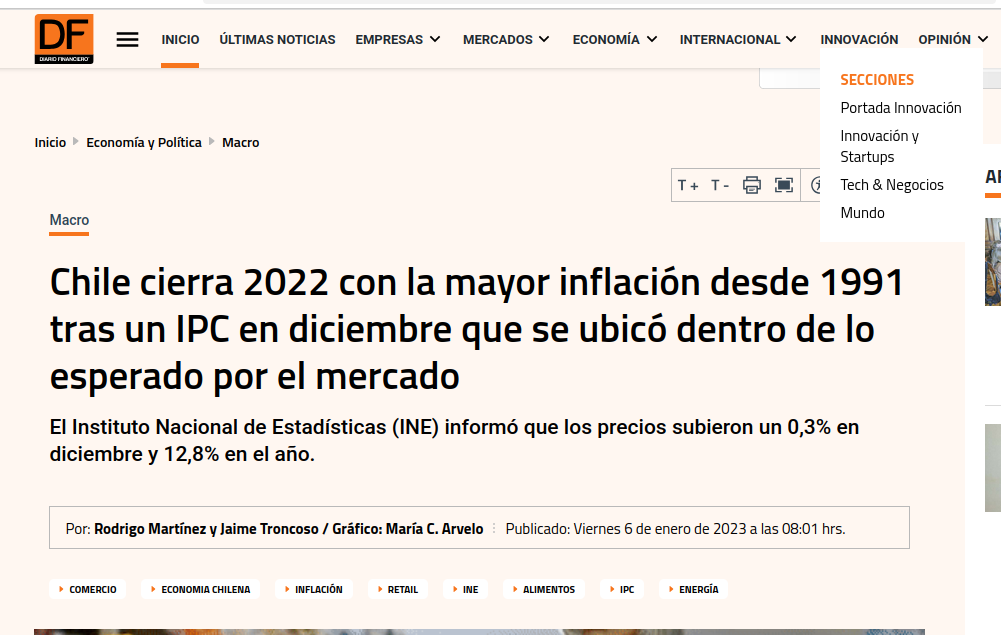

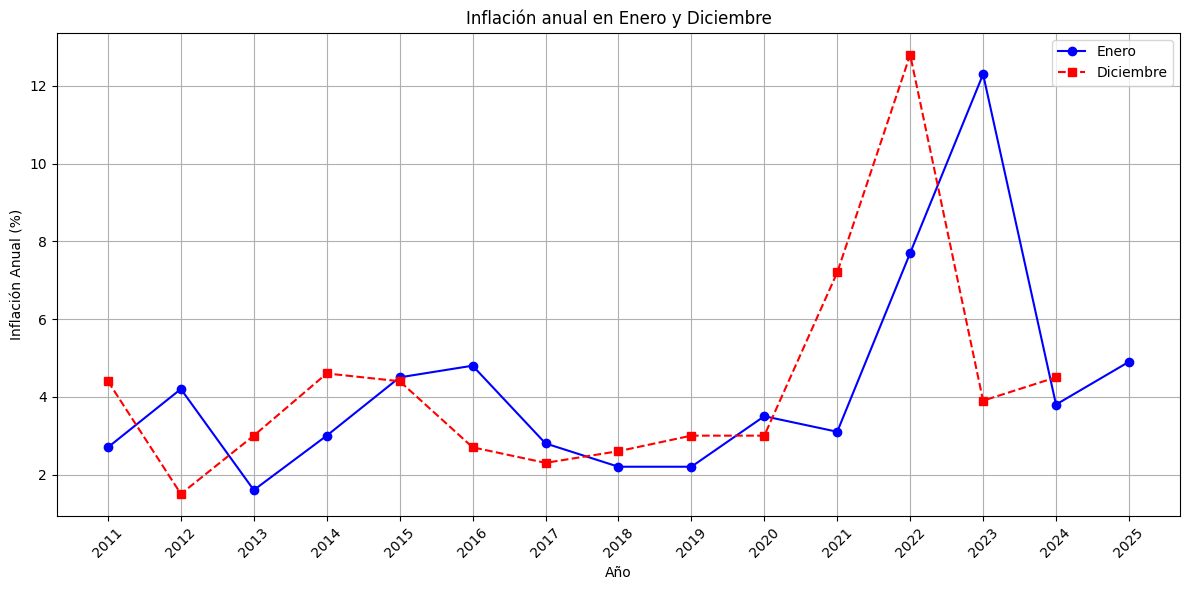

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegúrate de que 'fecha' esté en formato datetime
df_ipc['fecha'] = pd.to_datetime(df_ipc['fecha'], errors='coerce')

# Eliminar filas con fechas o valores 'anual' nulos
df_ipc = df_ipc.dropna(subset=['fecha', 'anual'])

# Extraer año y mes
df_ipc['anio'] = df_ipc['fecha'].dt.year
df_ipc['mes'] = df_ipc['fecha'].dt.month

# Ordenar por fecha
df_ipc = df_ipc.sort_values(by='fecha')

# Agrupar por año y mes, tomando el último valor de 'anual' del mes
df_anual = df_ipc.groupby(['anio', 'mes'])['anual'].last().reset_index()

# Filtrar solo enero y diciembre
enero = df_anual[df_anual['mes'] == 1]
diciembre = df_anual[df_anual['mes'] == 12]

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(enero['anio'], enero['anual'], marker='o', label='Enero', color='blue')
plt.plot(diciembre['anio'], diciembre['anual'], marker='s', label='Diciembre', linestyle='--', color='red')
plt.title('Inflación anual en Enero y Diciembre')
plt.xlabel('Año')
plt.ylabel('Inflación Anual (%)')
plt.xticks(sorted(df_anual['anio'].unique()), rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


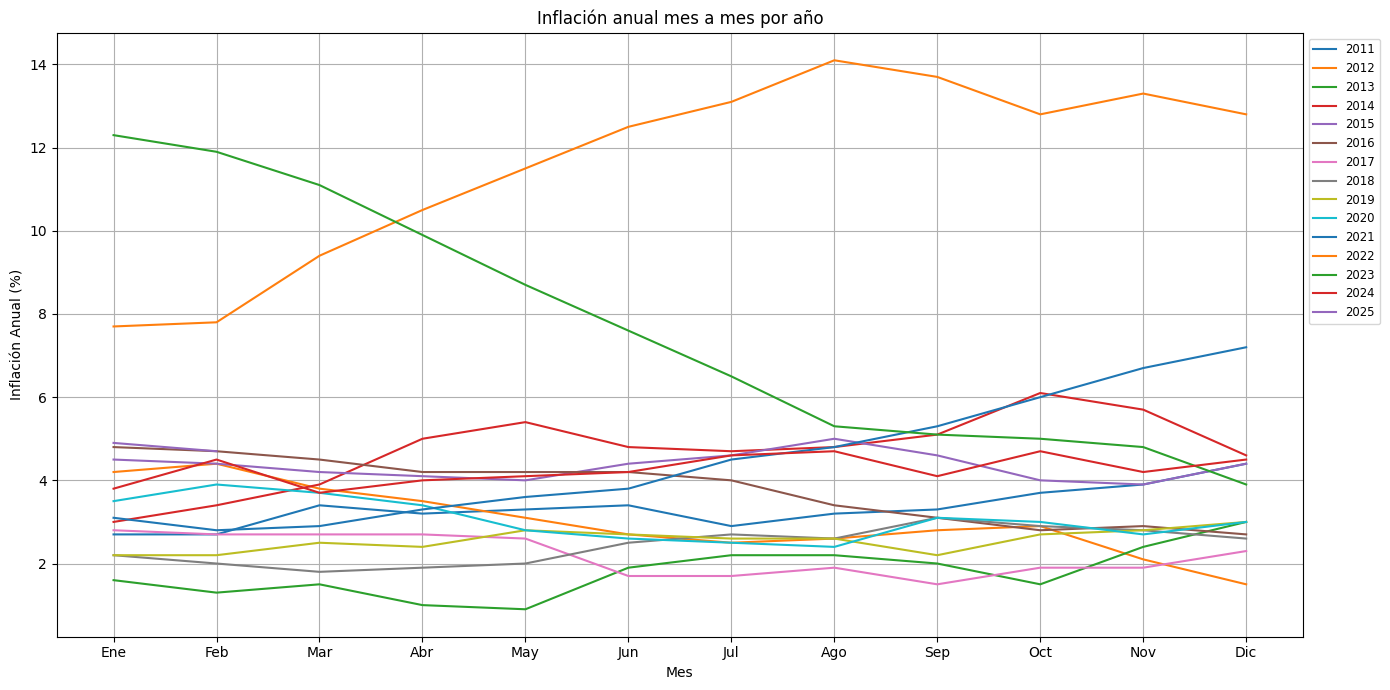

In [ ]:
# Pivotear para tener los meses como columnas y los años como filas
df_pivot = df_ipc.groupby(['anio', 'mes'])['anual'].last().unstack()

# Graficar líneas de cada año
plt.figure(figsize=(14, 7))
for year in df_pivot.index:
    plt.plot(range(1, 13), df_pivot.loc[year], label=str(year))
plt.title('Inflación anual mes a mes por año')
plt.xlabel('Mes')
plt.ylabel('Inflación Anual (%)')
plt.xticks(range(1, 13), ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1, fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

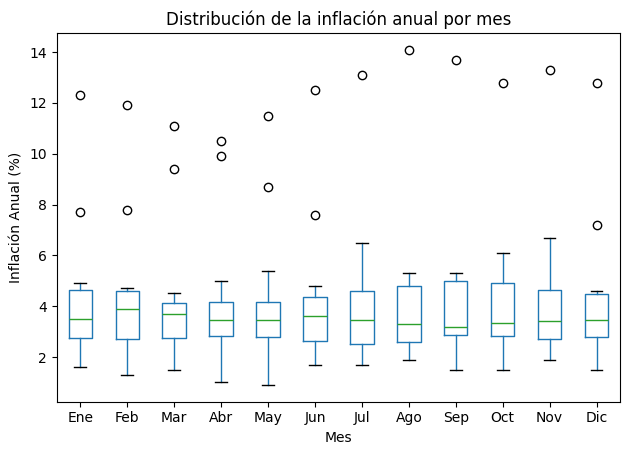

In [ ]:
# Agrupar y tomar últimos valores mensuales del año
df_anual = df_ipc.groupby(['anio', 'mes'])['anual'].last().reset_index()

# Boxplot por mes
plt.figure(figsize=(12, 6))
df_anual.boxplot(column='anual', by='mes', grid=False)
plt.title('Distribución de la inflación anual por mes')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Inflación Anual (%)')
plt.xticks(ticks=range(1, 13), labels=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()


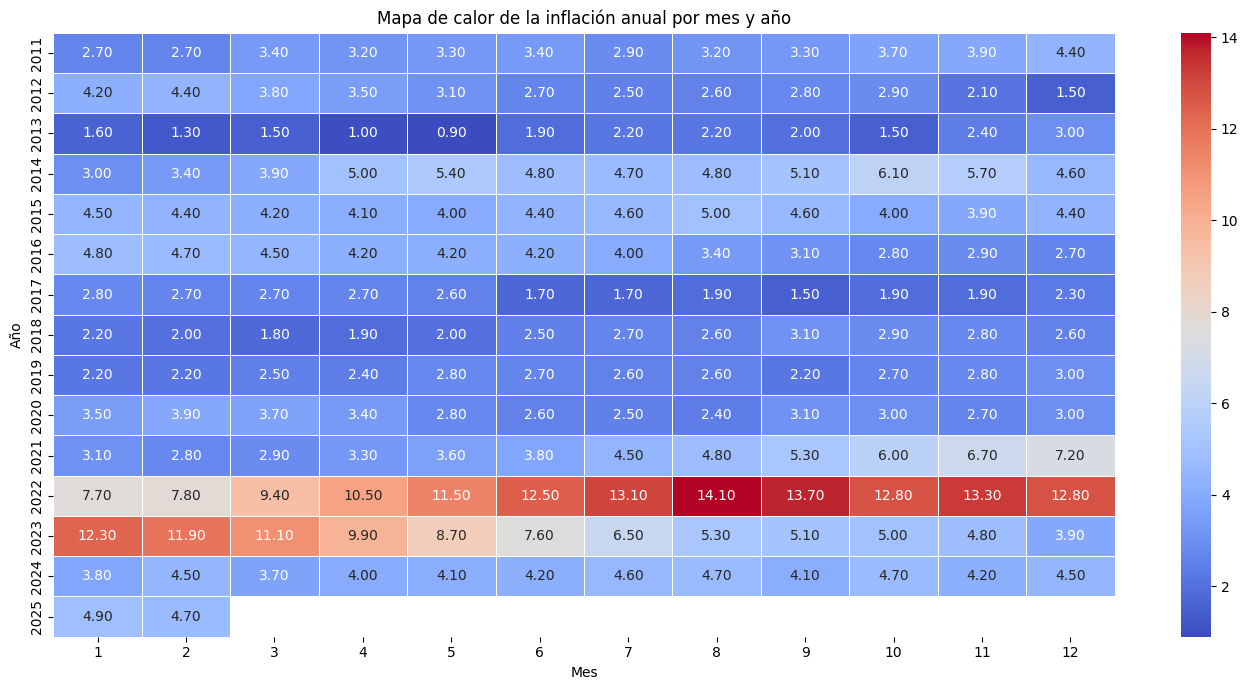

In [ ]:
import seaborn as sns

# Reutilizamos el pivot
df_pivot = df_ipc.groupby(['anio', 'mes'])['anual'].last().unstack()

# Mapa de calor
plt.figure(figsize=(14, 7))
sns.heatmap(df_pivot, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de calor de la inflación anual por mes y año')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.tight_layout()
plt.show()


## 💰 Retiros de Fondos de Pensiones en Chile: Impacto en la Economía

En respuesta a la crisis económica derivada de la pandemia, los ciudadanos chilenos pudieron realizar **tres retiros extraordinarios** de hasta el 10% de sus fondos previsionales desde sus cuentas en las AFP (Administradoras de Fondos de Pensiones).

### 📅 Fechas de Solicitud de los Retiros

- **Primer retiro**: 31 de julio de 2021  
- **Segundo retiro**: 10 de diciembre de 2021  
- **Tercer retiro**: 3 de mayo de 2022  

### 💸 Monto Permitido para el Retiro

El monto del retiro dependía del saldo acumulado en la cuenta individual del afiliado:

- Si el saldo era **mayor a 35 UF** y **menor o igual a 150 UF**, se podía retirar **hasta el 10%** de los fondos acumulados.
- Se establecieron **mínimos y máximos** en UF para resguardar la sostenibilidad de los fondos.

### 🏦 Operaciones y Desembolso Total

- Al **30 de diciembre de 2022**, se habían realizado un total de **28.833.877 operaciones de pago**.
- El **desembolso total acumulado** por los tres retiros fue de aproximadamente **US$ 48.339 millones**.

### 📊 Relevancia Económica

Este proceso tuvo un **fuerte impacto en la economía chilena**, incrementando la liquidez del mercado, pero también generando presiones inflacionarias al aumentar el consumo de bienes y servicios en un corto período de tiempo.

> Este contexto es clave para comprender las variaciones en indicadores económicos como el IPC, tipo de cambio, consumo interno y tasas de interés que se analizan en este notebook.


https://www.spensiones.cl/portal/institucional/594/w3-article-15478.html

# 📊 Análisis del IMACEC: Indicador Clave de la Actividad Económica en Chile

El **IMACEC** es uno de los principales indicadores utilizados para medir la evolución mensual de la actividad económica en Chile. Su seguimiento permite evaluar el desempeño de la economía nacional y proporciona información valiosa para la toma de decisiones en política económica.

### ¿Qué es el IMACEC?
El **IMACEC** refleja la variación mensual de la actividad económica en el país, considerando diferentes sectores productivos como la minería, el comercio, los servicios y la industria.

### ¿Por qué es importante el IMACEC?
Este indicador ofrece una visión rápida de la dinámica económica del país y sirve de referencia para analizar la salud de la economía en el corto plazo. Además, ayuda a anticipar posibles ajustes en políticas económicas y monetarias por parte del Banco Central de Chile.

### Evolución del IMACEC en los últimos meses
- El **IMACEC** se ha visto afectado por diversos factores, como los altos índices de inflación, la pandemia de COVID-19, y las fluctuaciones en los precios de los commodities.
- **En 2022 y 2023**, el IMACEC mostró señales de desaceleración en algunos sectores clave, lo que refleja una recuperación económica más lenta.

### Proyección a Futuro:
El IMACEC continuará siendo un dato fundamental para evaluar las tendencias económicas en Chile, ayudando a prever los movimientos en el mercado laboral, la inversión y la competitividad nacional.


In [ ]:
df_pivot

mes,1,2,3,4,5,6,7,8,9,10,11,12
anio,,,,,,,,,,,,
2011,2.7,2.7,3.4,3.2,3.3,3.4,2.9,3.2,3.3,3.7,3.9,4.4
2012,4.2,4.4,3.8,3.5,3.1,2.7,2.5,2.6,2.8,2.9,2.1,1.5
2013,1.6,1.3,1.5,1.0,0.9,1.9,2.2,2.2,2.0,1.5,2.4,3.0
2014,3.0,3.4,3.9,5.0,5.4,4.8,4.7,4.8,5.1,6.1,5.7,4.6
2015,4.5,4.4,4.2,4.1,4.0,4.4,4.6,5.0,4.6,4.0,3.9,4.4
2016,4.8,4.7,4.5,4.2,4.2,4.2,4.0,3.4,3.1,2.8,2.9,2.7
2017,2.8,2.7,2.7,2.7,2.6,1.7,1.7,1.9,1.5,1.9,1.9,2.3
2018,2.2,2.0,1.8,1.9,2.0,2.5,2.7,2.6,3.1,2.9,2.8,2.6
2019,2.2,2.2,2.5,2.4,2.8,2.7,2.6,2.6,2.2,2.7,2.8,3.0


### Justificación para aplicar una matriz de calor (Heatmap) en estos datos

En este conjunto de datos, que representa una serie temporal de valores por año y mes, una matriz de calor (heatmap) es una herramienta visual útil para mostrar patrones o tendencias subyacentes. A continuación se explican las razones y el tipo de datos involucrados:

#### 1. **Tipo de dato: Numérico continuo**
   - Los valores en cada fila representan mediciones numéricas continuas, que pueden estar relacionadas con variables como temperaturas, ventas o índices económicos mensuales.
   - Las matrices de calor son ideales para visualizar relaciones entre variables numéricas continuas, como es el caso aquí con los valores por año y mes.

#### 2. **Relaciones entre variables:**
   - Los datos contienen dos dimensiones clave: **año** y **mes**. Aplicar una matriz de calor permite visualizar rápidamente cómo cambian estos valores a lo largo del tiempo (año) y según la estacionalidad (mes).
   - Al utilizar una matriz de calor, se facilita la identificación de patrones cíclicos, tendencias estacionales o picos que ocurren durante ciertos meses del año, lo que puede ser difícil de detectar al mirar los datos en formato tabular.

#### 3. **Visibilidad de tendencias y patrones:**
   - Un heatmap destaca visualmente las fluctuaciones en los datos, lo que permite identificar rápidamente cualquier anomalía, pico, o periodo con comportamientos inusuales.
   - Por ejemplo, si se observa que los valores son más altos en los meses de verano (junio a agosto), esto puede sugerir una tendencia estacional o un patrón relacionado con el fenómeno observado.

#### 4. **Mejora en la toma de decisiones:**
   - Esta representación visual permite a los analistas y decisores observar y comprender las variaciones a lo largo del tiempo de forma rápida y eficiente. También puede ayudar en la toma de decisiones sobre cuándo intervenir o tomar acciones basadas en las fluctuaciones de los datos.

#### 5. **Facilidad de interpretación:**
   - Los heatmaps son intuitivos, con colores que varían desde el frío (bajo) al caliente (alto), lo que hace que la interpretación sea fácil incluso para personas sin experiencia técnica en análisis de datos.

#### Conclusión:
   - **Aplicar una matriz de calor a este conjunto de datos es una forma eficaz de visualizar las variaciones mensuales y anuales en los valores.** La representación gráfica facilita la identificación de patrones, estacionalidades y fluctuaciones que pueden no ser evidentes en una tabla tradicional.


In [ ]:
df_imacec = pd.read_excel("imacec.xls")

In [ ]:
df_imacec

,Mes,Valor
0,1997-01-01,6.167350
1,1997-02-01,5.038457
2,1997-03-01,5.602070
3,1997-04-01,5.997368
4,1997-05-01,7.948591
...,...,...
333,2024-10-01,2.624477
334,2024-11-01,2.324458
335,2024-12-01,6.773425
336,2025-01-01,2.304338


In [ ]:
df_imacec.describe()

,Mes,Valor
count,338,338.000000
mean,2011-01-15 15:41:32.307692288,3.499462
min,1997-01-01 00:00:00,-15.828851
25%,2004-01-08 18:00:00,1.462444
50%,2011-01-16 12:00:00,3.689513
75%,2018-01-24 06:00:00,5.706606
max,2025-02-01 00:00:00,20.446794
std,NaN,4.150185


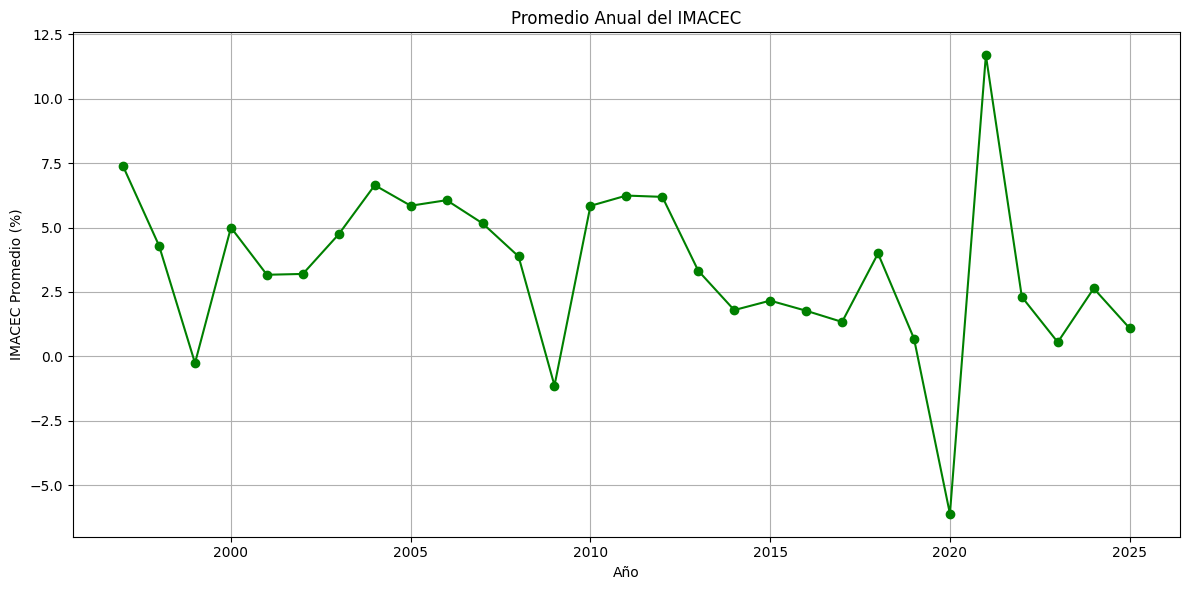

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que la columna de fechas esté en formato datetime
df_imacec['Mes'] = pd.to_datetime(df_imacec['Mes'])

# Extraer el año
df_imacec['Año'] = df_imacec['Mes'].dt.year

# Calcular el promedio anual
imacec_anual = df_imacec.groupby('Año')['Valor'].mean().reset_index()

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(imacec_anual['Año'], imacec_anual['Valor'], marker='o', color='green')
plt.title('Promedio Anual del IMACEC')
plt.xlabel('Año')
plt.ylabel('IMACEC Promedio (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


# 📉 Análisis del Desempleo en Chile: Evolución Mensual desde 2010

El desempleo es un indicador económico clave que refleja la proporción de la población activa que no encuentra trabajo. En Chile, este dato es seguido de cerca por economistas y autoridades para evaluar la salud del mercado laboral.

### Evolución del Desempleo en Chile (2010-2022)

A continuación, se muestran algunos de los valores más destacados del desempleo en Chile en los primeros años de la última década:

| **Mes**       | **Tasa de Desempleo** |
|---------------|-----------------------|
| 2010-03-01    | 9.23%                 |
| 2010-04-01    | 8.84%                 |
| ...           | ...                   |

### Análisis

- Durante **2010**, la tasa de desempleo mostró una leve disminución, lo que indica una mejora en las condiciones del mercado laboral en comparación con los meses anteriores.
  
- A lo largo de los años, la tasa de desempleo ha fluctuado debido a diversos factores, como crisis económicas, políticas gubernamentales y eventos internacionales.

### Factores Influyentes

- **Factores Internos**: La política económica nacional, los cambios en la industria, y las reformas laborales.
- **Factores Externos**: La situación económica global, las tasas de interés internacionales y los precios de los commodities.

### Tendencia a Futuro

El desempleo es un dato crucial para determinar la estabilidad económica. Las proyecciones para los próximos años dependen de la respuesta del gobierno y las políticas públicas ante


In [ ]:
df_desempleo = pd.read_excel("desempleo.xls")

In [ ]:
df_desempleo

,Mes,Valor
0,2010-03-01,9.227598
1,2010-04-01,8.836054
2,2010-05-01,9.087731
3,2010-06-01,8.656064
4,2010-07-01,8.511179
...,...,...
175,2024-10-01,8.580080
176,2024-11-01,8.217649
177,2024-12-01,8.079730
178,2025-01-01,8.023006


In [ ]:
df_desempleo.describe()

,Mes,Valor
count,180,180.000000
mean,2017-08-16 04:48:00,7.600285
min,2010-03-01 00:00:00,5.781732
25%,2013-11-23 12:00:00,6.668910
50%,2017-08-16 12:00:00,7.288114
75%,2021-05-08 18:00:00,8.321705
max,2025-02-01 00:00:00,13.091216
std,NaN,1.351598


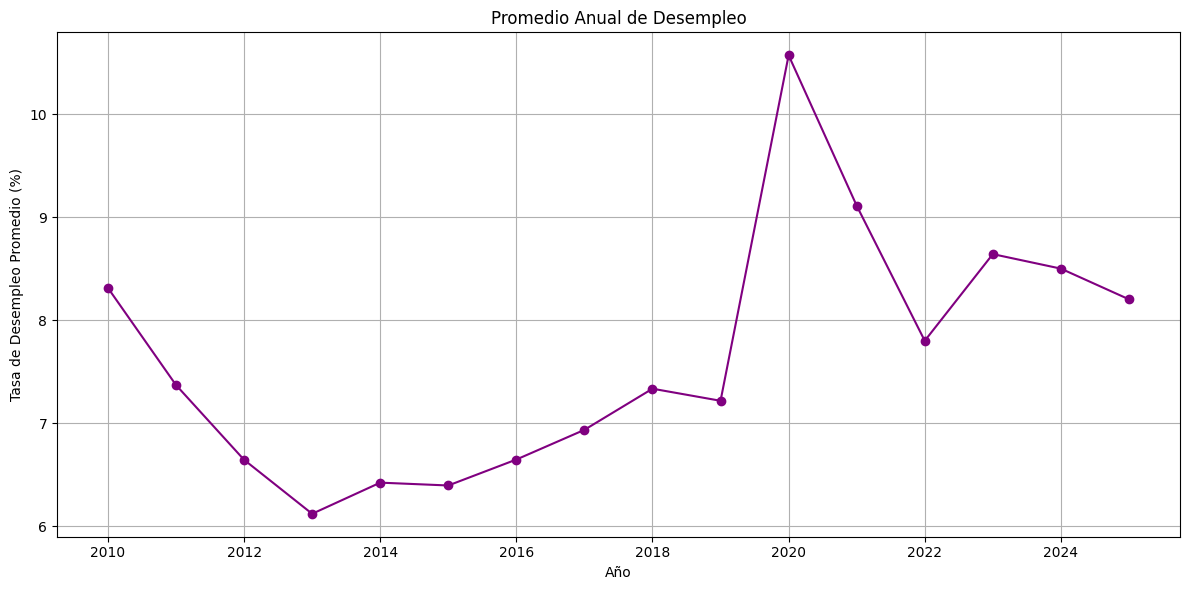

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurarse de que la columna 'Mes' esté en formato datetime
df_desempleo['Mes'] = pd.to_datetime(df_desempleo['Mes'])

# Extraer el año
df_desempleo['Año'] = df_desempleo['Mes'].dt.year

# Calcular promedio anual de desempleo
desempleo_anual = df_desempleo.groupby('Año')['Valor'].mean().reset_index()

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(desempleo_anual['Año'], desempleo_anual['Valor'], marker='o', color='purple')
plt.title('Promedio Anual de Desempleo')
plt.xlabel('Año')
plt.ylabel('Tasa de Desempleo Promedio (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


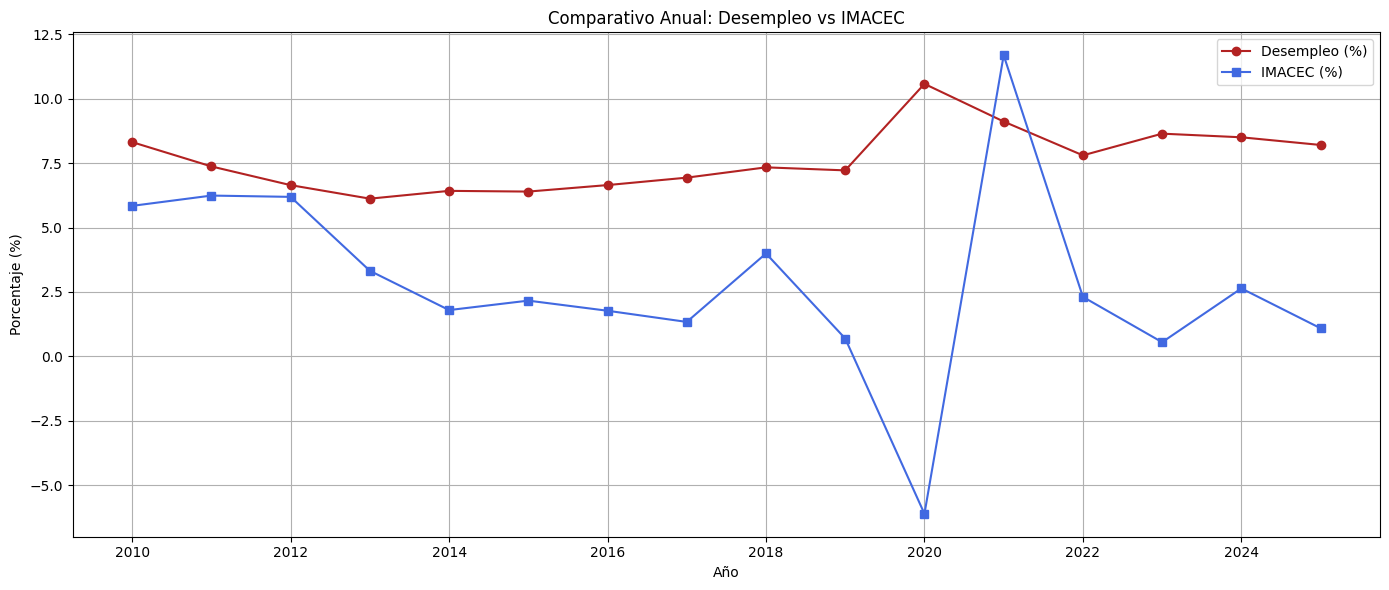

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar formato datetime
df_desempleo['Mes'] = pd.to_datetime(df_desempleo['Mes'])
df_imacec['Mes'] = pd.to_datetime(df_imacec['Mes'])

# Agregar columna Año
df_desempleo['Año'] = df_desempleo['Mes'].dt.year
df_imacec['Año'] = df_imacec['Mes'].dt.year

# Promedios anuales
desempleo_anual = df_desempleo.groupby('Año')['Valor'].mean().reset_index(name='Desempleo')
imacec_anual = df_imacec.groupby('Año')['Valor'].mean().reset_index(name='IMACEC')

# Unir ambos DataFrames por año
df_comparativo = pd.merge(desempleo_anual, imacec_anual, on='Año')

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(df_comparativo['Año'], df_comparativo['Desempleo'], marker='o', label='Desempleo (%)', color='firebrick')
plt.plot(df_comparativo['Año'], df_comparativo['IMACEC'], marker='s', label='IMACEC (%)', color='royalblue')
plt.title('Comparativo Anual: Desempleo vs IMACEC')
plt.xlabel('Año')
plt.ylabel('Porcentaje (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 📊 Análisis del Producto Interno Bruto (PIB) de Chile por Trimestre

El **Producto Interno Bruto (PIB)** es uno de los principales indicadores económicos utilizados para medir la salud económica de un país. Representa el valor total de los bienes y servicios producidos dentro de las fronteras de un país durante un período determinado, usualmente un trimestre o un año.

### ¿Qué es el PIB?

El PIB es una medida que refleja la actividad económica de un país y es crucial para entender el crecimiento o contracción económica. Existen tres enfoques principales para calcular el PIB:

1. **Enfoque de la producción**: Mide el valor agregado en cada etapa de producción de bienes y servicios.
2. **Enfoque del ingreso**: Mide el ingreso total generado por los factores de producción (salarios, rentas, beneficios empresariales).
3. **Enfoque del gasto**: Mide el gasto total en bienes y servicios dentro de la economía, considerando el consumo, la inversión, el gasto público y las exportaciones netas.

### Evolución Trimestral del PIB de Chile

A continuación, se observa cómo ha variado el PIB de Chile en los últimos trimestres. Los datos reflejan los ajustes económicos y las fluctuaciones estacionales en la economía nacional:

| **Trimestre**  | **PIB Real** (Crecimiento Anual) |
|----------------|----------------------------------|
| 2021-Q1        | 5.7%                             |
| 2021-Q2        | 11.8%                            |
| 2021-Q3        | 9.2%                             |
| 2021-Q4        | 6.5%                             |
| 2022-Q1        | 3.1%                             |
| ...            | ...                              |

### Análisis de los Datos Trimestrales

- **Crecimiento Positivo en 2021**: En los primeros trimestres de 2021, Chile experimentó un crecimiento significativo, con un fuerte rebote de la economía tras la desaceleración provocada por la pandemia de COVID-19. El crecimiento más alto se observó en el segundo trimestre, con una tasa de **11.8%**, impulsada por la reapertura de sectores económicos clave.

- **Estabilidad y Moderación en 2022**: A medida que avanzaba 2022, la tasa de crecimiento comenzó a moderarse, registrando un **3.1%** en el primer trimestre de ese año. Esto puede reflejar tanto un ajuste posterior al crecimiento impulsado por la pandemia como factores internos como la inflación y la incertidumbre política.

### Factores que Afectan el PIB Trimestral de Chile

- **Consumo interno**: El consumo de los hogares es una parte crucial del PIB, y cualquier cambio en el gasto de consumo impacta directamente en la tasa de crecimiento.
- **Inversión pública y privada**: Los proyectos de infraestructura y las decisiones de inversión empresarial pueden impulsar o frenar el crecimiento económico.
- **Sector exportador**: Chile es un importante exportador de recursos naturales, como cobre y litio, y las fluctuaciones en los precios internacionales de estos productos afectan la economía nacional.
- **Condiciones globales**: Factores como la inflación global, las políticas monetarias internacionales y la demanda externa influyen en la evolución del PIB.

### Conclusión

El análisis del PIB trimestral de Chile nos permite observar cómo se comporta la economía a lo largo del tiempo, identificando patrones de crecimiento o recesión. Es un indicador fundamental para diseñar políticas económicas que fomenten la estabilidad y el desarrollo.



In [ ]:
df_pib = pd.read_excel("pib.xls")

In [ ]:
df_pib

,Trimestre,Valor
0,1996-03-01,20264.762883
1,1996-06-01,20368.675683
2,1996-09-01,19581.248545
3,1996-12-01,21420.811496
4,1997-03-01,21401.297914
...,...,...
111,2023-12-01,53747.485776
112,2024-03-01,51629.653131
113,2024-06-01,51347.892689
114,2024-09-01,51072.569785


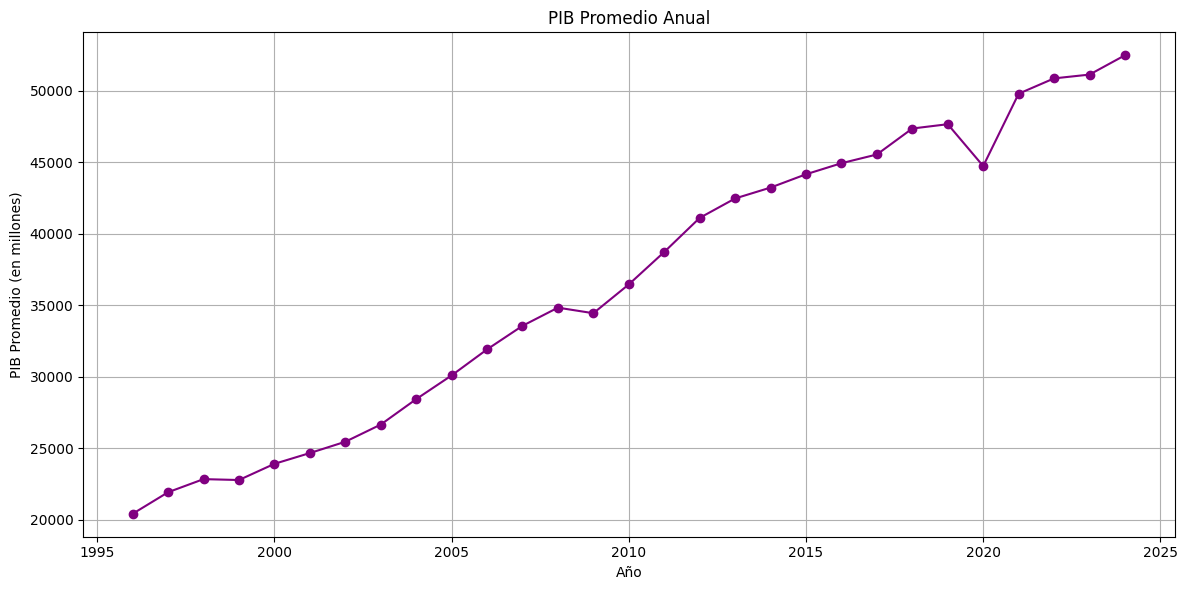

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que la columna de fechas esté en formato datetime
df_pib['Trimestre'] = pd.to_datetime(df_pib['Trimestre'])

# Extraer el año
df_pib['Año'] = df_pib['Trimestre'].dt.year

# Calcular el promedio anual del PIB
pib_anual = df_pib.groupby('Año')['Valor'].mean().reset_index()

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(pib_anual['Año'], pib_anual['Valor'], marker='o', linestyle='-', color='purple')
plt.title('PIB Promedio Anual')
plt.xlabel('Año')
plt.ylabel('PIB Promedio (en millones)')
plt.grid(True)
plt.tight_layout()
plt.show()


# 📊 Análisis de la Deuda Pública y su Relación con el Producto Interno Bruto (PIB) en Chile

La **deuda pública** es un concepto clave para entender la salud económica de un país. Refleja el monto total que un gobierno debe a los acreedores, ya sean nacionales o internacionales, y es una herramienta utilizada para financiar el gasto público cuando los ingresos son insuficientes. Es un indicador de la capacidad del gobierno para gestionar sus finanzas y su relación con el crecimiento económico, representado por el Producto Interno Bruto (PIB).

## ¿Qué es la Deuda Pública?

La deuda pública se refiere a la suma de los compromisos financieros que tiene el gobierno a nivel nacional. Este monto puede ser interno (cuando se debe a prestamistas dentro del país) o externo (cuando se debe a instituciones internacionales o gobiernos de otros países). El total de la deuda pública puede estar constituido por diversos componentes, entre ellos:

- **Deuda neta del gobierno central**: Es la deuda que el gobierno central tiene con sus acreedores, descontando los activos financieros que posee.
- **Deuda bruta del Banco Central**: Se refiere al total de los compromisos financieros del Banco Central, antes de deducir los activos que posee.
- **Deuda del sector público consolidado**: Engloba la deuda total del gobierno central, el Banco Central y otros organismos del sector público.
- **Deuda de las empresas públicas**: Incluye la deuda de las empresas estatales que operan bajo control del gobierno.

## Dataset de Deuda Pública

El siguiente conjunto de datos presenta la evolución de la deuda pública en Chile, reflejada en varias métricas desde 2006 hasta 2019:

| **Periodo**   | **Deuda Pública** | **Deuda Neta Gobierno Central** | **Deuda Bruta Banco Central** | **Deuda Neta Banco Central** | **Deuda Bruta Sector Público Consolidado** | **Deuda Neta Sector Público Consolidado** | **Deuda Bruta Empresas Públicas** | **Deuda Neta Empresas Públicas** |
|---------------|-------------------|---------------------------------|-------------------------------|-----------------------------|--------------------------------------------|----------------------------------------|---------------------------------|-----------------------------------|
| 2006-01-01    | 5.02%             | -6.67%                          | 15.72%                        | 0.84%                       | 18.55%                                     | -5.83%                                | 5.06%                           | 4.25%                             |
| 2007-01-01    | 3.90%             | -13.01%                         | 10.35%                        | 0.20%                       | 13.88%                                     | -12.80%                               | 4.79%                           | 3.42%                             |
| 2008-01-01    | 4.92%             | -19.26%                         | 13.40%                        | -3.32%                      | 18.07%                                     | -22.59%                               | 6.50%                           | 5.92%                             |
| 2009-01-01    | 5.84%             | -10.58%                         | 15.51%                        | -1.48%                      | 20.97%                                     | -12.07%                               | 6.28%                           | 5.56%                             |
| 2010-01-01    | 8.61%             | -7.04%                          | 11.16%                        | -0.73%                      | 19.36%                                     | -7.77%                                | 6.17%                           | 5.55%                             |
| 2011-01-01    | 11.13%            | -8.60%                          | 16.96%                        | -1.96%                      | 27.06%                                     | -10.55%                               | 6.69%                           | 5.62%                             |
| 2012-01-01    | 11.94%            | -6.77%                          | 15.19%                        | -1.09%                      | 26.29%                                     | -7.86%                                | 6.95%                           | 5.98%                             |
| 2013-01-01    | 12.78%            | -5.65%                          | 13.54%                        | -2.24%                      | 25.77%                                     | -7.89%                                | 7.67%                           | 6.84%                             |
| 2014-01-01    | 15.02%            | -4.37%                          | 13.65%                        | -3.08%                      | 27.80%                                     | -7.44%                                | 9.08%                           | 7.99%                             |
| 2015-01-01    | 17.37%            | -3.46%                          | 12.80%                        | -4.53%                      | 29.92%                                     | -7.99%                                | 10.13%                          | 8.97%                             |
| 2016-01-01    | 21.10%            | 0.94%                           | 12.42%                        | -3.66%                      | 32.87%                                     | -2.72%                                | 9.33%                           | 8.79%                             |
| 2017-01-01    | 23.65%            | 4.42%                           | 10.54%                        | -3.05%                      | 33.80%                                     | 1.37%                                 | 8.56%                           | 7.65%                             |
| 2018-01-01    | 25.80%            | 5.74%                           | 10.54%                        | -4.16%                      | 35.80%                                     | 1.58%                                 | 9.32%                           | 8.32%                             |
| 2019-01-01    | 28.33%            | 7.99%                           | 10.57%                        | -5.71%                      | 38.56%                                     | 2.29%                                 | N/A                             | N/A                               |

## ¿Qué es la Deuda Pública en Relación al PIB?

La deuda pública de un país es importante para evaluar su sostenibilidad financiera. Se utiliza comúnmente el **ratio de deuda sobre el PIB** para medir la relación entre la deuda total de un país y el tamaño de su economía. Si el ratio es alto, puede ser señal de que el país tiene una carga de deuda elevada, lo que podría poner en riesgo su capacidad para cumplir con los pagos de intereses y el principal. Si es bajo, indica que el país tiene mayor capacidad de endeudamiento sin comprometer la estabilidad económica.

El ratio de deuda sobre el PIB puede influir en la percepción de los inversionistas sobre la solidez económica de un país, y afectar su calificación crediticia.

### **Factores que Influyen en la Deuda Pública**:
- **Política fiscal**: Los gobiernos que gastan más de lo que recaudan en impuestos tienden a endeudarse.
- **Crecimiento económico**: Un mayor crecimiento del PIB puede reducir el ratio de deuda, ya que el crecimiento económico puede aumentar los ingresos fiscales.
- **Tasas de interés**: El costo de la deuda está determinado por las tasas de interés; tasas altas pueden aumentar la carga de la deuda.
- **Eventos excepcionales**: Crisis económicas, desastres naturales, o gastos imprevistos pueden llevar a un aumento de la deuda pública.

## Conclusión

El análisis de la deuda pública en relación con el PIB es crucial para entender la salud financiera de un país. En el caso de Chile, la deuda pública ha mostrado un aumento significativo en los últimos años, lo que podría reflejar tanto mayores necesidades de financiamiento como una economía que ha enfrentado desafíos en su gestión fiscal. Este tipo de análisis es fundamental para la formulación de políticas públicas que busquen un equilibrio entre el gasto público y la sostenibilidad fiscal.



In [ ]:
df_deuda_publica_pib = pd.read_excel("deuda_publica_pib.xlsx")

In [ ]:
df_deuda_publica_pib

,Periodo,deuda_publica,deuda_neta_gobierno_central,deuda_bruta_banco_central,deuda_neta_banco_central,deuda_bruta_sector_publico_consolidado,deuda_neta_sector_publico_consolidado,deuda_bruta_empresas_publicas,deuda_neta_empresas_publicas
0,2006-01-01,5.022398,-6.666478,15.724155,0.837735,18.548172,-5.828743,5.061372,4.246094
1,2007-01-01,3.901260,-13.005539,10.350593,0.200724,13.881071,-12.804815,4.786793,3.415271
2,2008-01-01,4.915989,-19.264949,13.396463,-3.320525,18.072288,-22.585475,6.502579,5.920946
3,2009-01-01,5.844926,-10.582554,15.513890,-1.482524,20.967801,-12.065077,6.283777,5.563484
4,2010-01-01,8.607328,-7.040119,11.159892,-0.732545,19.358651,-7.772665,6.168078,5.547010
5,2011-01-01,11.126890,-8.596503,16.956867,-1.957186,27.062849,-10.553688,6.692305,5.621012
6,2012-01-01,11.939073,-6.770777,15.194894,-1.092849,26.286772,-7.863626,6.945123,5.979421
7,2013-01-01,12.784064,-5.646367,13.541349,-2.240870,25.773509,-7.887237,7.670990,6.835790
8,2014-01-01,15.019748,-4.368878,13.648906,-3.075925,27.800139,-7.444803,9.077742,7.990843
9,2015-01-01,17.374660,-3.459618,12.800960,-4.534903,29.924353,-7.994521,10.131672,8.972927


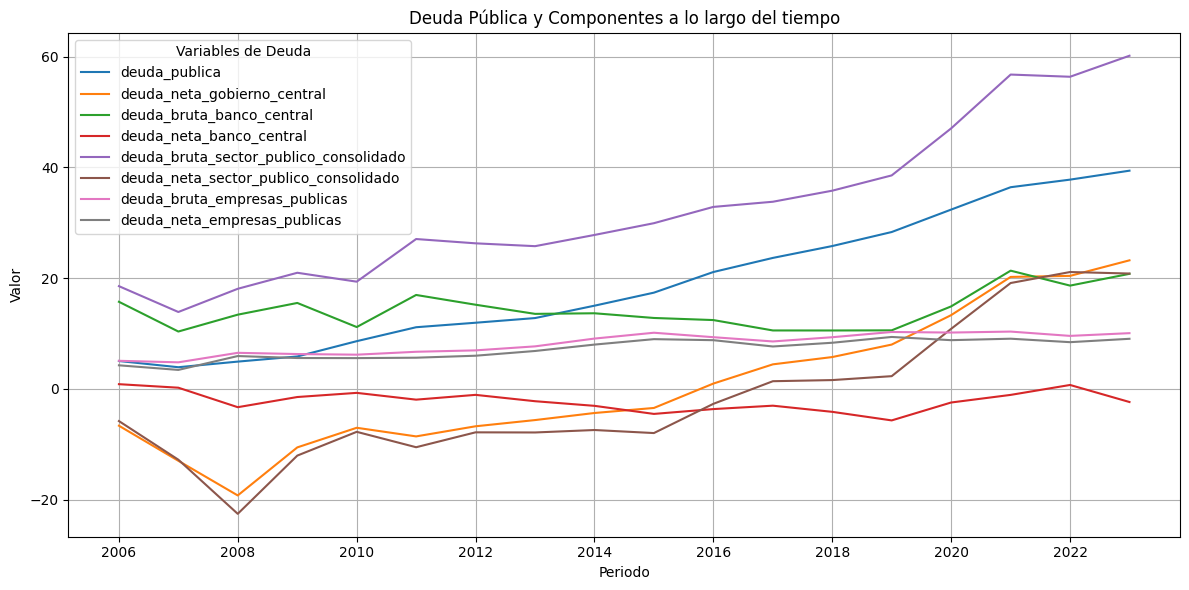

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegúrate de que 'Periodo' esté en formato datetime
df_deuda_publica_pib['Periodo'] = pd.to_datetime(df_deuda_publica_pib['Periodo'])

# Crear el gráfico
plt.figure(figsize=(12, 6))

# Graficar todas las columnas de deuda (excluyendo 'Periodo')
for column in df_deuda_publica_pib.columns[1:]:  # Excluimos la primera columna que es 'Periodo'
    plt.plot(df_deuda_publica_pib['Periodo'], df_deuda_publica_pib[column], label=column)

# Etiquetas y título
plt.title('Deuda Pública y Componentes a lo largo del tiempo')
plt.xlabel('Periodo')
plt.ylabel('Valor')
plt.legend(title='Variables de Deuda')
plt.grid(True)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


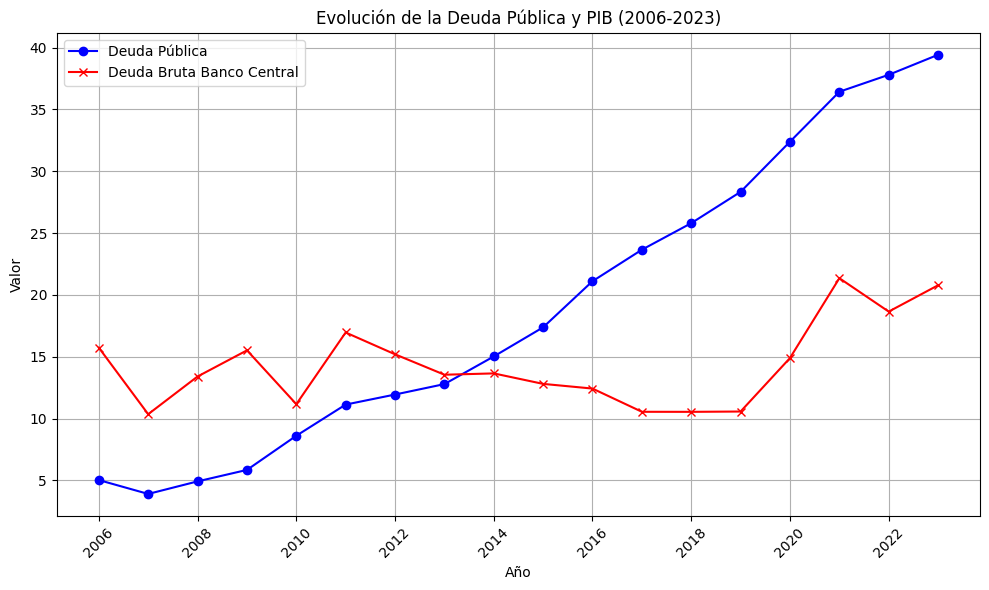

In [ ]:
df_deuda_publica_pib['Periodo'] = pd.to_datetime(df_deuda_publica_pib['Periodo'])

# Graficar los datos
plt.figure(figsize=(10, 6))

# Graficar la deuda pública
plt.plot(df_deuda_publica_pib['Periodo'], df_deuda_publica_pib['deuda_publica'], label='Deuda Pública', color='blue', marker='o')

# Graficar el PIB
plt.plot(df_deuda_publica_pib['Periodo'], df_deuda_publica_pib['deuda_bruta_banco_central'], label='Deuda Bruta Banco Central', color='red', marker='x')

plt.xlabel('Año')
plt.ylabel('Valor')
plt.title('Evolución de la Deuda Pública y PIB (2006-2023)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

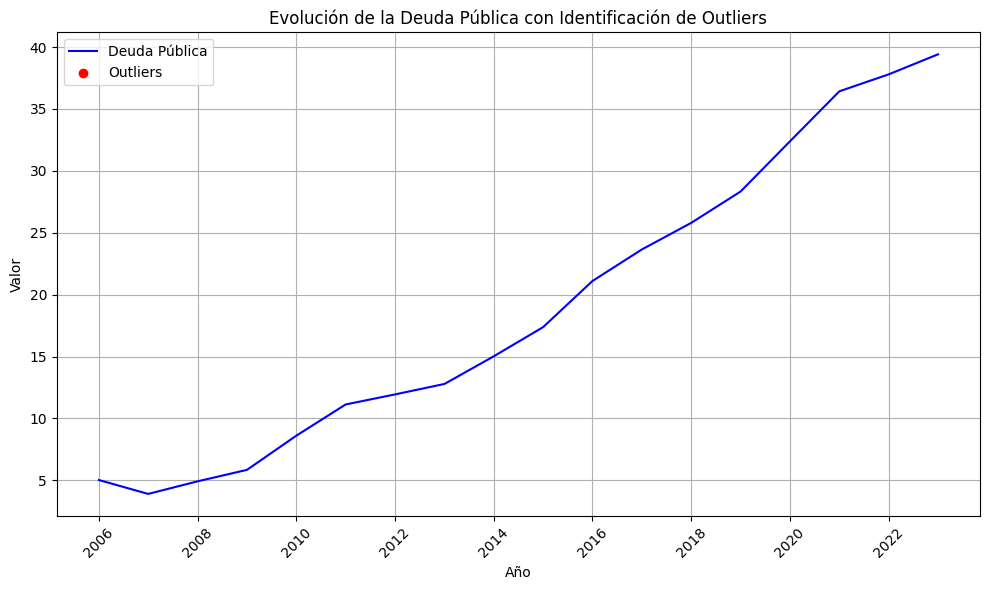

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calcular la tasa de crecimiento
df_deuda_publica_pib['tasa_crecimiento_deuda_publica'] = df_deuda_publica_pib['deuda_publica'].pct_change() * 100
df_deuda_publica_pib['tasa_crecimiento_deuda_bruta'] = df_deuda_publica_pib['deuda_bruta_banco_central'].pct_change() * 100

# Identificar outliers utilizando el rango intercuartílico
Q1 = df_deuda_publica_pib['deuda_publica'].quantile(0.25)
Q3 = df_deuda_publica_pib['deuda_publica'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_deuda_publica_pib[(df_deuda_publica_pib['deuda_publica'] > Q3 + 1.5 * IQR) |
                                 (df_deuda_publica_pib['deuda_publica'] < Q1 - 1.5 * IQR)]

# Graficar la deuda pública y los outliers
plt.figure(figsize=(10, 6))
plt.plot(df_deuda_publica_pib['Periodo'], df_deuda_publica_pib['deuda_publica'], label='Deuda Pública', color='blue')
plt.scatter(outliers['Periodo'], outliers['deuda_publica'], color='red', label='Outliers')
plt.xlabel('Año')
plt.ylabel('Valor')
plt.title('Evolución de la Deuda Pública con Identificación de Outliers')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


https://www.spensiones.cl/apps/bdp/index.php

## 📄 Diccionario de Datos — Inversiones AFP

Este conjunto de datos contiene información detallada sobre las operaciones de inversión realizadas por las AFP en diversos instrumentos financieros.

---

### 🗓️ Información Temporal

- **`fecha`**: Fecha de la operación, en formato numérico `YYYYMMDD`.

---

### 🏢 Entidad Inversionista

- **`afp`**: Nombre o código de la Administradora de Fondos de Pensiones (AFP) que realiza la inversión.
- **`tipo_de_fondo`**: Tipo de fondo administrado por la AFP (ej. Fondo A, B, C, D, E).

---

### 📈 Información del Instrumento Financiero

- **`tipo_de_instrumento`**: Tipo de instrumento financiero (ej. bonos, acciones, instrumentos estructurados).
- **`nemotecnico_del_instrumento`**: Código o nombre que identifica al instrumento.
- **`nombre_del_emisor`**: Nombre de la entidad emisora del instrumento (ej. banco, empresa, gobierno).
- **`nacionalidad_del_emisor`**: País de origen del emisor del instrumento.
- **`unidad_de_reajuste_de_moneda`**: Unidad de reajuste aplicada a la moneda (ej. UF, USD, CLP).

---

### 💰 Detalles de la Operación

- **`unidades`**: Cantidad de unidades del instrumento financiero adquiridas.
- **`precio`**: Precio unitario del instrumento en la fecha de la operación.
- **`inversion`**: Monto total invertido en la operación (precio * unidades).

---

### 🏦 Información Complementaria

- **`grupo_economico`**: Grupo económico o sector al que pertenece el emisor del instrumento.

---

### 💱 Contratos Derivados (Forward & Swap)

#### Forward
- **`moneda_contrato_forward`**: Moneda utilizada en el contrato forward.
- **`moneda_objeto_forward`**: Moneda objetivo del contrato forward.
- **`precio_ejercicio_forward`**: Precio de ejercicio pactado en el contrato forward.

#### Swap
- **`plazo_economico`**: Plazo acordado de la operación de swap.
- **`tasa_pactada_del_fondo_swap`**: Tasa pactada del fondo en el contrato swap.
- **`tasa_pactada_de_la_contraparte_swap`**: Tasa pactada de la contraparte en el contrato swap.

---

> Este diccionario es útil para comprender los distintos campos del dataset antes de realizar análisis exploratorios, agregaciones o visualizaciones con Pandas y Matplotlib.


In [ ]:
import pandas as pd
import os

# Crear un DataFrame vacío para almacenar los datos concatenados
df_todos_anos = pd.DataFrame()

# Iterar desde 2016 hasta 2024
for annio in range(2016, 2025):
    # Crear el nombre del archivo con el año
    archivo = f"cartera_mensual_{annio}.csv"

    # Verificar si el archivo existe antes de intentar leerlo
    if os.path.exists(archivo):
        try:
            # Leer el archivo CSV
            df_cartera = pd.read_csv(archivo, sep=";", encoding='ISO-8859-1')

            # Concatenar los datos al DataFrame principal
            df_todos_anos = pd.concat([df_todos_anos, df_cartera], ignore_index=True)
            print(f"Datos del año {annio} cargados correctamente.")
        except Exception as e:
            print(f"No se pudo leer el archivo {archivo}: {e}")
    else:
        print(f"El archivo {archivo} no se encuentra.")

# Ahora df_todos_anos contiene los datos concatenados de todos los años
# Si quieres guardar el DataFrame resultante en un archivo CSV, puedes hacerlo:
df_todos_anos.to_csv("cartera_mensual_total.csv", index=False, sep=";")


Datos del año 2016 cargados correctamente.
Datos del año 2017 cargados correctamente.


<ipython-input-46-ae4c6433a57d>:16: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cartera = pd.read_csv(archivo, sep=";", encoding='ISO-8859-1')


Datos del año 2018 cargados correctamente.
Datos del año 2019 cargados correctamente.
Datos del año 2020 cargados correctamente.
Datos del año 2021 cargados correctamente.


<ipython-input-46-ae4c6433a57d>:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cartera = pd.read_csv(archivo, sep=";", encoding='ISO-8859-1')


Datos del año 2022 cargados correctamente.
Datos del año 2023 cargados correctamente.
Datos del año 2024 cargados correctamente.


In [ ]:
df_todos_anos.tail()

,fecha,afp,tipo_de_fondo,tipo_de_instrumento,nemotecnico_del_instrumento,nombre_del_emisor,nacionalidad_del_emisor,unidad_de_reajuste_de_moneda,unidades,precio,inversion,grupo_economico,moneda_contrato_forward,moneda_objeto_forward,precio_ejercicio_forward,plazo_economico,tasa_pactada_del_fondo_swap,tasa_pactada_de_la_contraparte_swap
3352155,20241129,uno,E,SNT,STDUS$340428240429,BANCO SANTANDER CHILE,,NaN,3000000.0,39.461151,1.183835e+08,14.0,NaN,NaN,NaN,NaN,"SFRUS$360+00,0000ACT/360","FIJAUS$+04,3270ACT/360"
3352156,20241129,uno,E,SNT,STDUS$340912240912,BANCO SANTANDER CHILE,,NaN,7500000.0,-46.139379,-3.460453e+08,14.0,NaN,NaN,NaN,NaN,"SFRUS$360+00,0000ACT/360","FIJAUS$+03,2110ACT/360"
3352157,20241129,uno,E,SNT,STDUS$340920240916,BANCO SANTANDER CHILE,,NaN,3475000.0,-45.822303,-1.592325e+08,14.0,NaN,NaN,NaN,NaN,"SFRUS$360+00,0000ACT/360","FIJAUS$+03,2130ACT/360"
3352158,20241129,uno,E,SNT,STDUS$340920240917,BANCO SANTANDER CHILE,,NaN,2900000.0,-47.639952,-1.381559e+08,14.0,NaN,NaN,NaN,NaN,"SFRUS$360+00,0000ACT/360","FIJAUS$+03,1900ACT/360"
3352159,20241129,uno,E,SNT,STDUS$540810240809,BANCO SANTANDER CHILE,,NaN,1200000.0,-57.522665,-6.902720e+07,14.0,NaN,NaN,NaN,NaN,"SFRUS$360+00,0000ACT/360","FIJAUS$+03,4020ACT/360"


In [ ]:
df_todos_anos.columns

Index(['fecha', 'afp', 'tipo_de_fondo', 'tipo_de_instrumento',
       'nemotecnico_del_instrumento', 'nombre_del_emisor',
       'nacionalidad_del_emisor', 'unidad_de_reajuste_de_moneda', 'unidades',
       'precio', 'inversion', 'grupo_economico', 'moneda_contrato_forward',
       'moneda_objeto_forward', 'precio_ejercicio_forward', 'plazo_economico',
       'tasa_pactada_del_fondo_swap', 'tasa_pactada_de_la_contraparte_swap'],
      dtype='object')

In [ ]:
df_todos_anos.isnull().sum()

,0
fecha,0
afp,20
tipo_de_fondo,20
tipo_de_instrumento,20
nemotecnico_del_instrumento,20
nombre_del_emisor,20
nacionalidad_del_emisor,20
unidad_de_reajuste_de_moneda,1055297
unidades,20
precio,20


In [ ]:
afp_distribution = df_todos_anos['afp'].value_counts()
print(afp_distribution)


afp
cup    674946
prv    624082
cap    591148
hab    542887
pli    404248
mod    379663
uno    135166
Name: count, dtype: int64


In [ ]:
df_filtrado = df_todos_anos[df_todos_anos['inversion'] > 1e8]  # Filtra inversiones mayores a 100 millones
print(df_filtrado)


            fecha  afp tipo_de_fondo tipo_de_instrumento  \
1        20160129  hab             A                 BTU   
3        20160129  hab             A                 BTU   
5        20160129  hab             A                 BTP   
6        20160129  prv             A                 BTP   
7        20160129  prv             A                 BTU   
...           ...  ...           ...                 ...   
3351923  20241129  prv             E                YSET   
3351924  20241129  prv             E                YSET   
3351925  20241129  prv             E                YSET   
3352154  20241129  uno             E                 SNT   
3352155  20241129  uno             E                 SNT   

        nemotecnico_del_instrumento                    nombre_del_emisor  \
1                        BTU0300130    TESORERIA GENERAL DE LA REPUBLICA   
3                        BTU0300339    TESORERIA GENERAL DE LA REPUBLICA   
5                        BTP0600122    TESORERIA GE

In [ ]:
df_todos_anos_numericos = df_todos_anos.select_dtypes(include=['float64', 'int64'])
correlation_matrix = df_todos_anos_numericos.corr()
print(correlation_matrix)


                          unidades    precio  inversion  grupo_economico  \
unidades                  1.000000 -0.010144   0.187054        -0.052520   
precio                   -0.010144  1.000000   0.022939         0.021071   
inversion                 0.187054  0.022939   1.000000        -0.000016   
grupo_economico          -0.052520  0.021071  -0.000016         1.000000   
precio_ejercicio_forward -0.034318  0.286943   0.096663        -0.141659   
plazo_economico           0.049798  0.460613   0.158409         0.118544   

                          precio_ejercicio_forward  plazo_economico  
unidades                                 -0.034318         0.049798  
precio                                    0.286943         0.460613  
inversion                                 0.096663         0.158409  
grupo_economico                          -0.141659         0.118544  
precio_ejercicio_forward                  1.000000              NaN  
plazo_economico                                

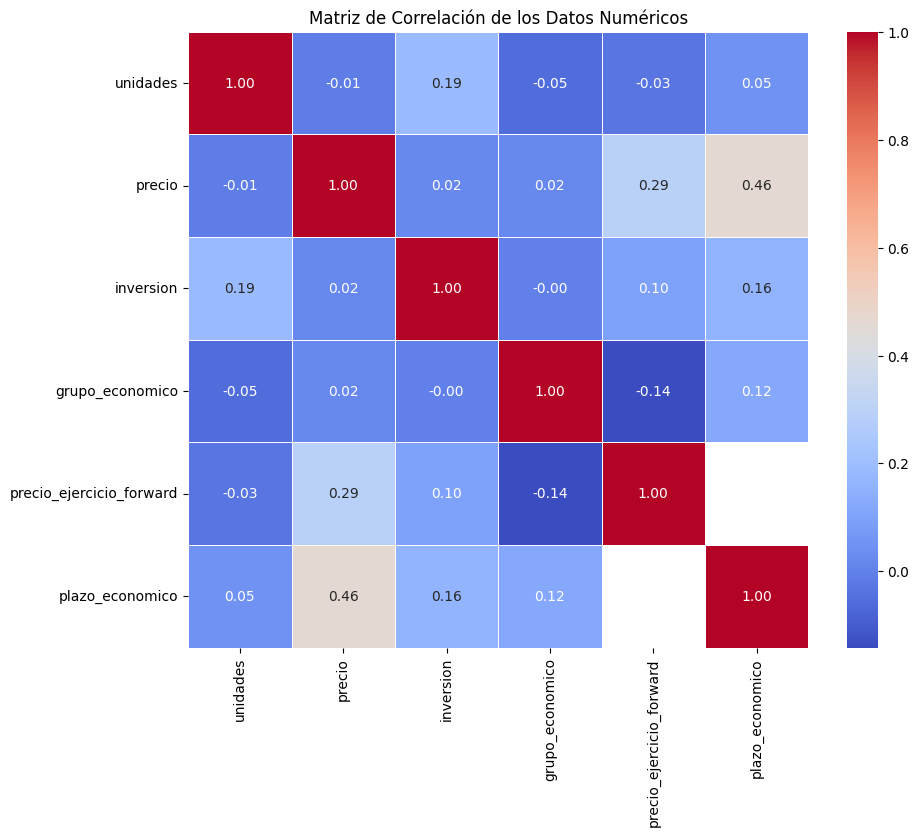

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que los datos numéricos estén seleccionados
df_todos_anos_numericos = df_todos_anos.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix = df_todos_anos_numericos.corr()

# Graficar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación de los Datos Numéricos")
plt.show()


In [ ]:
afps = df_todos_anos.groupby(df_todos_anos['afp'])
print(afps.groups.keys())

fondos_afp = df_todos_anos.groupby(df_todos_anos['tipo_de_fondo'])
print(fondos_afp.groups.keys())

dict_keys(['cap', 'cup', 'hab', 'mod', 'pli', 'prv', 'uno'])
dict_keys(['A', 'B', 'C', 'D', 'E'])


# Continuará...

### Nota sobre la catalogación política

La clasificación política de los eventos representados en el gráfico fue realizada a partir de una recomendación proporcionada por ChatGPT, basada en el contexto histórico y político de cada presidente en función de su tendencia ideológica generalizada. Es importante destacar que esta clasificación no refleja ninguna postura ni apoyo hacia un partido o tendencia política en particular, sino que se utiliza con fines ilustrativos y analíticos. La intención de este gráfico es representar la distribución de eventos a lo largo de los años de manera objetiva y sin ningún sesgo político.


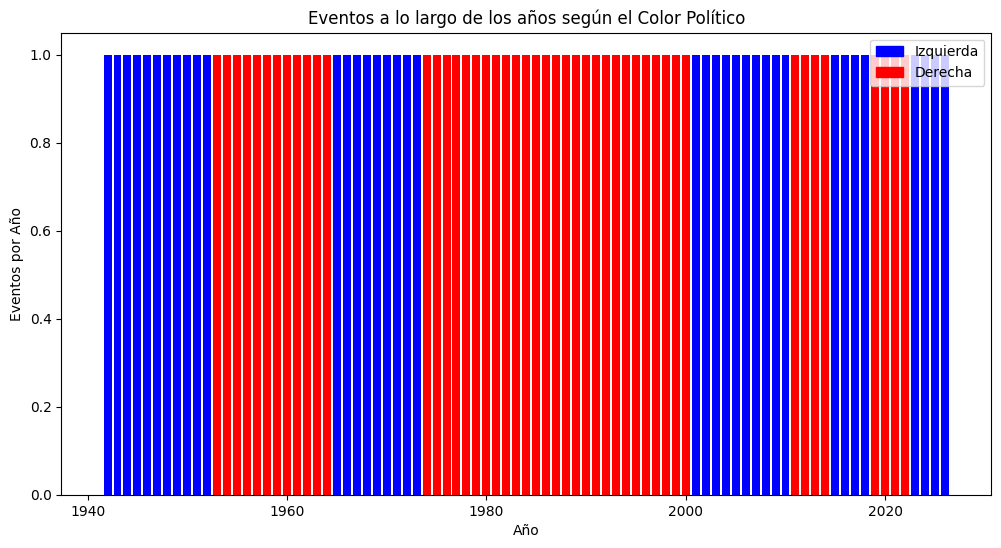

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Datos de ejemplo sobre eventos o registros con fechas
data_eventos = {
    'inicio_evento': [1942, 1946, 1952, 1958, 1964, 1970, 1973, 1990, 1994, 2000, 2006, 2010, 2014, 2018, 2022],
    'termino_evento': [1946, 1952, 1958, 1964, 1970, 1973, 1990, 1994, 2000, 2006, 2010, 2014, 2018, 2022, 2026],
    'evento': ['Juan Antonio Ríos', 'Gabriel González Videla', 'Carlos Ibáñez del Campo',
               'Jorge Alessandri', 'Eduardo Frei Montalva', 'Salvador Allende',
               'Augusto Pinochet', 'Patricio Aylwin', 'Eduardo Frei Ruiz-Tagle',
               'Ricardo Lagos', 'Michelle Bachelet', 'Sebastián Piñera',
               'Michelle Bachelet', 'Sebastián Piñera', 'Gabriel Boric'],
    'color_politico': ['izquierda', 'izquierda', 'derecha', 'derecha', 'izquierda', 'izquierda',
                       'derecha', 'derecha', 'derecha', 'izquierda', 'izquierda', 'derecha',
                       'izquierda', 'derecha', 'izquierda'],
    'color': ['blue', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red',
              'blue', 'red', 'blue']
}

# Crear DataFrame
df_eventos = pd.DataFrame(data_eventos)

# Asignar colores para la gráfica
color_map = {'izquierda': 'blue', 'derecha': 'red'}

# Crear gráfico de barras para cada año
years = range(df_eventos['inicio_evento'].min(), df_eventos['termino_evento'].max() + 1)
event_colors = []

for year in years:
    # Asignar el color político del evento para ese año
    color = df_eventos[(df_eventos['inicio_evento'] <= year) & (df_eventos['termino_evento'] >= year)]['color'].values
    if len(color) > 0:
        event_colors.append(color[0])
    else:
        event_colors.append('gray')

# Crear gráfico
plt.figure(figsize=(12, 6))
plt.bar(years, [1] * len(years), color=event_colors)

# Etiquetas y título
plt.xlabel('Año')
plt.ylabel('Eventos por Año')
plt.title('Eventos a lo largo de los años según el Color Político')

# Mostrar leyenda
legend_labels = [mpatches.Patch(color='blue', label='Izquierda'),
                 mpatches.Patch(color='red', label='Derecha')]
plt.legend(handles=legend_labels)

# Mostrar gráfico
plt.show()


In [ ]:
df_eventos

,inicio_evento,termino_evento,evento,color_politico,color
0,1942,1946,Juan Antonio Ríos,izquierda,blue
1,1946,1952,Gabriel González Videla,izquierda,blue
2,1952,1958,Carlos Ibáñez del Campo,derecha,red
3,1958,1964,Jorge Alessandri,derecha,red
4,1964,1970,Eduardo Frei Montalva,izquierda,blue
5,1970,1973,Salvador Allende,izquierda,blue
6,1973,1990,Augusto Pinochet,derecha,red
7,1990,1994,Patricio Aylwin,derecha,red
8,1994,2000,Eduardo Frei Ruiz-Tagle,derecha,red
9,2000,2006,Ricardo Lagos,izquierda,blue


         Mes     Valor   Año      fecha color
0 1997-01-01  6.167350  1997 1997-01-01   red
1 1997-02-01  5.038457  1997 1997-02-01   red
2 1997-03-01  5.602070  1997 1997-03-01   red
3 1997-04-01  5.997368  1997 1997-04-01   red
4 1997-05-01  7.948591  1997 1997-05-01   red


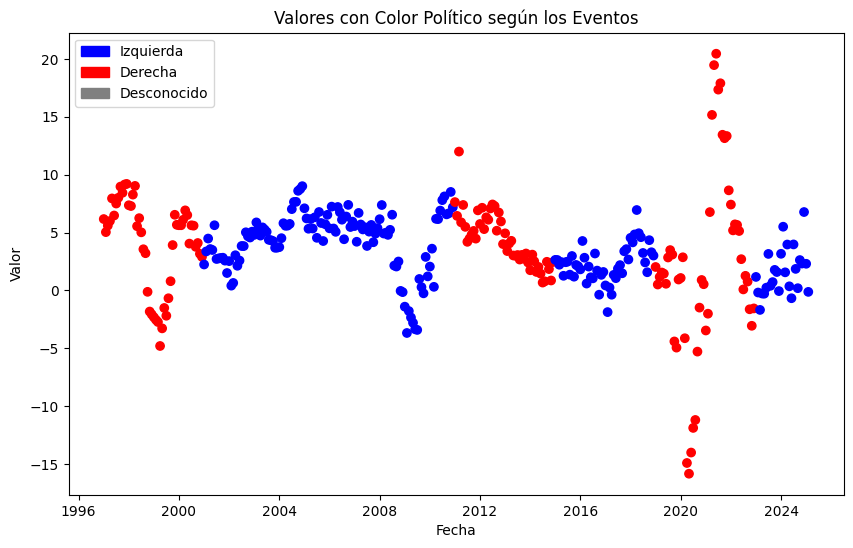

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurarse de que la columna de fechas esté en formato datetime
df_imacec['fecha'] = pd.to_datetime(df_imacec['Mes'])

# Función para asignar el color político en función de la fecha
def asignar_color_politico(fecha):
    # Filtrar eventos que ocurren durante la fecha dada
    evento_actual = df_eventos[(df_eventos['inicio_evento'] <= fecha.year) &
                               (df_eventos['termino_evento'] >= fecha.year)]

    if not evento_actual.empty:
        # Si se encuentra un evento, se retorna el color asociado
        return evento_actual['color'].iloc[0]
    else:
        # Si no se encuentra un evento en ese período, asignar color 'gray'
        return 'gray'

# Aplicar la función a cada fila de df_imacec para asignar el color
df_imacec['color'] = df_imacec['fecha'].apply(asignar_color_politico)

# Ver el resultado
print(df_imacec.head())

# Graficar los valores con color según el color político
plt.figure(figsize=(10, 6))
plt.scatter(df_imacec['fecha'], df_imacec['Valor'], c=df_imacec['color'], label="Eventos")
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('Valores con Color Político según los Eventos')

# Mostrar la leyenda
import matplotlib.patches as mpatches
legend_labels = [mpatches.Patch(color='blue', label='Izquierda'),
                 mpatches.Patch(color='red', label='Derecha'),
                 mpatches.Patch(color='gray', label='Desconocido')]
plt.legend(handles=legend_labels)

plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Convertir las fechas a características numéricas
df_imacec['fecha_num'] = (df_imacec['fecha'] - df_imacec['fecha'].min()).dt.days

# Codificar el color político
label_encoder = LabelEncoder()
df_imacec['color_encoded'] = label_encoder.fit_transform(df_imacec['color'])

# Separar las características (X) y el valor objetivo (y)
X = df_imacec[['fecha_num', 'color_encoded']]
y = df_imacec['Valor']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo de regresión
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Hacer predicciones
y_pred = modelo.predict(X_test)

# Evaluar el rendimiento del modelo
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f'Error cuadrático medio (MSE): {mse}')


Error cuadrático medio (MSE): 14.990351980044862


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Separar las características (X) y el color político (y)
X = df_imacec[['fecha_num', 'Valor']]  # Se puede agregar más características si lo deseas
y = df_imacec['color']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el clasificador
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Hacer predicciones
y_pred = clf.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del clasificador: {accuracy}')


Precisión del clasificador: 1.0


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, X, y, cv=5)  # Realiza validación cruzada con 5 particiones
print(f'Precisión promedio en validación cruzada: {scores.mean()}')


Precisión promedio en validación cruzada: 0.7211150131694469


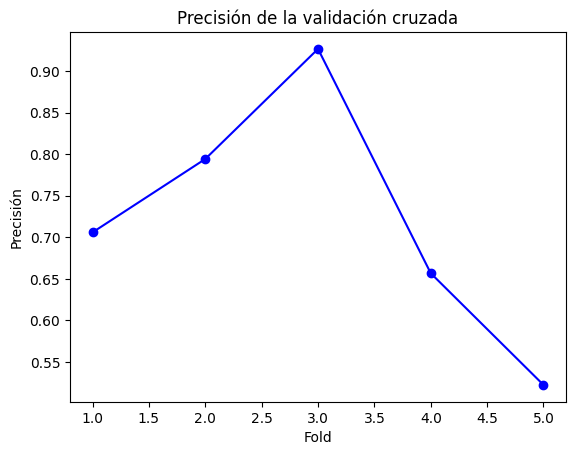

Precisión promedio: 0.7211150131694469


In [ ]:
import matplotlib.pyplot as plt

# Visualizar las puntuaciones de la validación cruzada
plt.plot(range(1, len(scores)+1), scores, marker='o', linestyle='-', color='b')
plt.xlabel('Fold')
plt.ylabel('Precisión')
plt.title('Precisión de la validación cruzada')
plt.show()

print(f'Precisión promedio: {scores.mean()}')


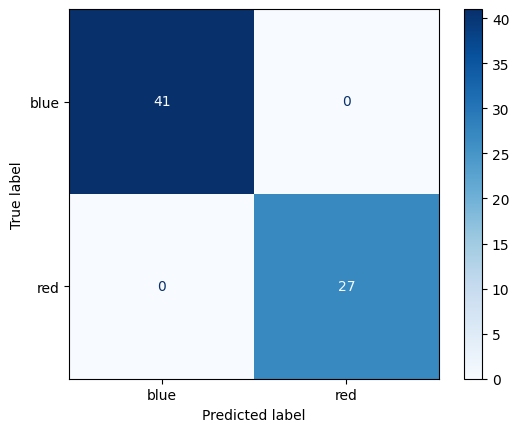

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.show()


In [ ]:
df_imacec.head()

,Mes,Valor,Año,fecha,color,fecha_num,color_encoded
0,1997-01-01,6.167350,1997,1997-01-01,red,0,1
1,1997-02-01,5.038457,1997,1997-02-01,red,31,1
2,1997-03-01,5.602070,1997,1997-03-01,red,59,1
3,1997-04-01,5.997368,1997,1997-04-01,red,90,1
4,1997-05-01,7.948591,1997,1997-05-01,red,120,1


In [ ]:
# Aplicar One-Hot Encoding a la columna 'color'
df_encoded = pd.get_dummies(df_imacec, columns=['color'])

# Mostrar el DataFrame resultante
print(df_encoded)

           Mes     Valor   Año      fecha  fecha_num  color_encoded  \
0   1997-01-01  6.167350  1997 1997-01-01          0              1   
1   1997-02-01  5.038457  1997 1997-02-01         31              1   
2   1997-03-01  5.602070  1997 1997-03-01         59              1   
3   1997-04-01  5.997368  1997 1997-04-01         90              1   
4   1997-05-01  7.948591  1997 1997-05-01        120              1   
..         ...       ...   ...        ...        ...            ...   
333 2024-10-01  2.624477  2024 2024-10-01      10135              0   
334 2024-11-01  2.324458  2024 2024-11-01      10166              0   
335 2024-12-01  6.773425  2024 2024-12-01      10196              0   
336 2025-01-01  2.304338  2025 2025-01-01      10227              0   
337 2025-02-01 -0.122891  2025 2025-02-01      10258              0   

     color_blue  color_red  
0         False       True  
1         False       True  
2         False       True  
3         False       True  
4 

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(f'Mejores parámetros: {grid_search.best_params_}')


Mejores parámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Aplicar los mejores parámetros al modelo
clf_best = RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=100, random_state=42)

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
clf_best.fit(X_train, y_train)

# Hacer predicciones
y_pred_best = clf_best.predict(X_test)

# Evaluar el rendimiento
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f'Precisión en el conjunto de prueba: {accuracy_best}')

# Evaluar en el conjunto de validación cruzada
from sklearn.model_selection import cross_val_score
cv_scores_best = cross_val_score(clf_best, X, y, cv=5)
print(f'Precisión promedio en validación cruzada: {cv_scores_best.mean()}')


Precisión en el conjunto de prueba: 1.0
Precisión promedio en validación cruzada: 0.6912642669007902


In [ ]:
#RAM

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(f'Mejores parámetros ajustados: {grid_search.best_params_}')


Mejores parámetros ajustados: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)
print(f'Matriz de Confusión:\n{cm}')

# Reporte de clasificación
print(f'\nReporte de clasificación:\n{classification_report(y_test, y_pred_best)}')


Matriz de Confusión:
[[41  0]
 [ 0 27]]

Reporte de clasificación:
              precision    recall  f1-score   support

        blue       1.00      1.00      1.00        41
         red       1.00      1.00      1.00        27

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



In [ ]:
# Datos de entrada con 4 características
nuevos_datos = [[1.5, 2.3, 3.1, 4.0]]

# Selecciona solo las primeras 2 características
nuevos_datos_seleccionados = nuevos_datos[0][:2]  # Esto selecciona solo [1.5, 2.3]

# Realiza la predicción con las 2 características
prediccion = modelo.predict([nuevos_datos_seleccionados])
print(f'Predicción: {prediccion}')


Predicción: [5.21184473]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Cargar tus datos en un DataFrame
data = {
    'Valor': [6.167350, 5.038457, 5.602070, 5.997368, 7.948591, 2.624477, 2.324458, 6.773425, 2.304338, -0.122891],
    'Año': [1997, 1997, 1997, 1997, 1997, 2024, 2024, 2024, 2025, 2025],
    'fecha_num': [729025, 729056, 729084, 729115, 729145, 739160, 739191, 739221, 739252, 739283],
    'color_blue': [False, False, False, False, False, True, True, True, True, True],
    'color_red': [True, True, True, True, True, False, False, False, False, False]
}

df = pd.DataFrame(data)

# Preparar las características (X) y las etiquetas (y)
X = df[['Valor', 'Año', 'fecha_num']]  # Características
y = df['color_blue']  # Etiquetas (color azul)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
print(f'Matriz de Confusión:\n{confusion_matrix(y_test, y_pred)}\n')
print(f'Reporte de Clasificación:\n{classification_report(y_test, y_pred)}')


Matriz de Confusión:
[[1 0]
 [0 1]]

Reporte de Clasificación:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00         1
        True       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:
# Datos de entrada con 4 características
nuevos_datos = [[1.5, 2.3, 3.1, 4.0]]

# Selecciona solo las primeras 2 características
nuevos_datos_seleccionados = nuevos_datos[0][:2]  # Esto selecciona solo [1.5, 2.3]

# Realiza la predicción con las 2 características
prediccion = modelo.predict([nuevos_datos_seleccionados])
print(f'Predicción: {prediccion}')


Predicción: [5.21184473]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Eliminar filas con valores nulos
df_encoded_clean = df_encoded.dropna()

# Calcular la matriz de correlación
correlation_matrix = df_encoded_clean.corr()

# Mostrar la matriz de correlación
print(correlation_matrix)


                    Mes     Valor       Año     fecha  fecha_num  \
Mes            1.000000 -0.218981  0.999370  1.000000   1.000000   
Valor         -0.218981  1.000000 -0.219530 -0.218981  -0.218981   
Año            0.999370 -0.219530  1.000000  0.999370   0.999370   
fecha          1.000000 -0.218981  0.999370  1.000000   1.000000   
fecha_num      1.000000 -0.218981  0.999370  1.000000   1.000000   
color_encoded -0.008832  0.009368 -0.009092 -0.008832  -0.008832   
color_blue     0.008832 -0.009368  0.009092  0.008832   0.008832   
color_red     -0.008832  0.009368 -0.009092 -0.008832  -0.008832   

               color_encoded  color_blue  color_red  
Mes                -0.008832    0.008832  -0.008832  
Valor               0.009368   -0.009368   0.009368  
Año                -0.009092    0.009092  -0.009092  
fecha              -0.008832    0.008832  -0.008832  
fecha_num          -0.008832    0.008832  -0.008832  
color_encoded       1.000000   -1.000000   1.000000  
color_blu

### ¿Cuándo Codificar?

La codificación de variables categóricas es esencial para modelos que solo pueden manejar variables numéricas, como la regresión lineal. Aquí te doy una guía para decidir cuándo y cómo usar alguna codificación:

#### Antes de entrenar el modelo:
One-Hot Encoding o alguna técnica de codificación debe aplicarse antes de entrenar el modelo, ya que los modelos como la regresión lineal no pueden procesar variables categóricas directamente.

### ¿Cuándo usar One-Hot Encoding?
- **Cuando las variables son categóricas nominales** (sin un orden lógico, como `color`, `ciudad`, `producto`).
  - **Ejemplo**: Si tienes una columna `color` con valores como "rojo", "azul", "verde", debes usar **One-Hot Encoding** para convertirla en varias columnas binarias.
  
- **Cuando hay un número limitado de categorías**: Si una columna tiene demasiadas categorías (más de 10-15), el **One-Hot Encoding** puede generar demasiadas columnas, lo que aumentaría la dimensionalidad y afectaría el rendimiento del modelo.

### ¿Cuándo usar Label Encoding?
- **Cuando las variables son categóricas ordinales** (con un orden lógico, como `tamaño` con valores "Pequeño", "Medio", "Grande").
  - **Ejemplo**: Usar **Label Encoding** asignando valores numéricos (1, 2, 3) a las categorías de `tamaño` para que el modelo pueda entender el orden implícito entre las categorías.

### ¿Cuándo usar otros tipos de codificación?
- **Cuando las variables categóricas tienen demasiadas categorías**: Si una variable tiene muchas categorías (más de 50-100), **One-Hot Encoding** podría no ser adecuado por la alta dimensionalidad que crea. En ese caso, podrías considerar usar:
  - **Target Encoding**: Asigna el valor promedio de la variable objetivo a cada categoría.
  - **Frequency Encoding**: Asigna el número de veces que aparece cada categoría en el conjunto de datos.

### Verificación de los Datos Antes de Codificar:
- **Tamaño de las categorías**: Revisa cuántas categorías tiene cada variable. Si son pocas, usa **One-Hot Encoding**. Si son muchas, evalúa otras codificaciones.
- **Posibles valores faltantes**: Asegúrate de que no haya valores faltantes en las columnas categóricas. Si los hay, decide cómo manejarlos (rellenarlos o eliminarlos).

### Resumen:

Antes de aplicar técnicas de codificación, es importante entender los tipos de variables categóricas:

- **Variables categóricas**: Son aquellas que toman un conjunto limitado de valores o categorías. Se dividen en:
  - **Variables nominales**: No tienen un orden intrínseco entre sus categorías. Ejemplo: Colores de coche (rojo, azul, verde).
  - **Variables ordinales**: Tienen un orden implícito entre sus categorías. Ejemplo: Tiempos de espera (bajo, medio, alto).

### Técnicas de codificación:

- **Codificación antes de entrenar**: Convierte todas las variables categóricas en variables numéricas antes de entrenar el modelo. Esto es crucial para que los algoritmos de machine learning, que requieren datos numéricos, puedan procesar estas variables.

- **One-Hot Encoding**:
  - **Uso**: Se utiliza cuando las variables son **categóricas nominales** y tienen un número razonable de categorías.
  - **Ejemplo**: Si tienes una variable "Color" con categorías `rojo`, `azul` y `verde`, el One-Hot Encoding creará tres columnas:
    - `Color_Rojo`, `Color_Azul`, `Color_Verde`
    - Si un coche es rojo, la fila correspondiente tendrá el valor `[1, 0, 0]`.
  - **Significado**: Esta técnica representa cada categoría como una columna separada con valores binarios (0 o 1).

- **Label Encoding**:
  - **Uso**: Se utiliza para variables **ordinales**, donde existe un orden implícito entre las categorías.
  - **Ejemplo**: Si tienes una variable "Tamaño" con categorías `pequeño`, `mediano` y `grande`, el Label Encoding las convierte a valores numéricos:
    - `pequeño = 0`, `mediano = 1`, `grande = 2`
  - **Significado**: Asigna un número entero a cada categoría según su orden.

- **Binary Encoding**:
  - **Uso**: Es útil cuando tienes un gran número de categorías y buscas reducir la dimensionalidad.
  - **Ejemplo**: Para una variable "Producto" con muchas categorías, el Binary Encoding convierte cada categoría a su representación binaria, reduciendo el número de columnas en comparación con One-Hot Encoding.
  - **Significado**: Convierte las categorías en valores binarios y los coloca en columnas, lo que resulta en una codificación más eficiente en términos de memoria.




In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Ejemplo: Regresión Lineal para predecir 'Valor'
X = df_encoded[['Año', 'fecha_num', 'color_blue', 'color_red']]  # Variables predictoras
y = df_encoded['Valor']  # Variable objetivo

# Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo usando el error cuadrático medio
mse = mean_squared_error(y_test, y_pred)
print(f"Error cuadrático medio: {mse}")


Error cuadrático medio: 15.039613957920608


In [ ]:
"""
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
print("MSE promedio de validación cruzada:", -scores.mean())
"""

'\nfrom sklearn.model_selection import cross_val_score\nscores = cross_val_score(model, X_scaled, y, cv=5, scoring=\'neg_mean_squared_error\')\nprint("MSE promedio de validación cruzada:", -scores.mean())\n'

In [ ]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)  # Ajusta el valor de alpha
ridge_model.fit(X_train, y_train)


Ridge()

In [ ]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1)  # Ajusta el valor de alpha
lasso_model.fit(X_train, y_train)


Lasso(alpha=0.1)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Error cuadrático medio con Random Forest: {mse_rf}")


Error cuadrático medio con Random Forest: 2.0036819639760877


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_rf)
print(f"Coeficiente de determinación (R²): {r2}")


Coeficiente de determinación (R²): 0.8760802343012634


In [ ]:
# Obtener los coeficientes de la regresión lineal
coeficientes = model.coef_

# Crear un DataFrame para visualizar los coeficientes de las características
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coeficientes})

# Ordenar por valor absoluto del coeficiente para ver las características más influyentes
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Mostrar los coeficientes y la importancia de las características
print(coef_df)


      Feature  Coefficient  Abs_Coefficient
0         Año    -0.445870         0.445870
2  color_blue    -0.070807         0.070807
3   color_red     0.070807         0.070807
1   fecha_num     0.000935         0.000935


In [ ]:
from sklearn.model_selection import cross_val_score

# Realizar validación cruzada para obtener una estimación más robusta del rendimiento
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

# Mostrar los resultados de la validación cruzada
print(f"Errores cuadráticos medios de validación cruzada: {-cv_scores}")
print(f"Promedio de MSE de validación cruzada: {-cv_scores.mean()}")


Errores cuadráticos medios de validación cruzada: [18.84321428  9.28898093 12.98528185  3.14170496 52.34125499]
Promedio de MSE de validación cruzada: 19.320087401478396


In [ ]:
# Importar librerías necesarias
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Suponiendo que ya tienes el dataframe 'df_encoded' con las características adecuadas.
# Asegúrate de que tu dataframe tiene las columnas necesarias para predecir 'Valor'.

# Variables predictoras y la variable objetivo
X = df_encoded[['Año', 'fecha_num', 'color_blue', 'color_red']]  # Variables predictoras
y = df_encoded['Valor']  # Variable objetivo

# Normalización de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- 1. Modelo de Regresión Lineal ---
# Inicializar y entrenar el modelo de regresión lineal
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_linear = linear_model.predict(X_test)

# Evaluar el modelo usando el error cuadrático medio (MSE)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = linear_model.score(X_test, y_test)

print(f"Error cuadrático medio (MSE) para la regresión lineal: {mse_linear}")
print(f"Coeficiente de determinación (R²) para la regresión lineal: {r2_linear}")

# --- 2. Validación cruzada para Regresión Lineal ---
# Evaluar el modelo de regresión lineal usando validación cruzada
cv_scores_linear = cross_val_score(linear_model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
cv_mse_linear = -cv_scores_linear  # Convertir los valores negativos de MSE a positivos
print(f"Errores cuadráticos medios de validación cruzada (Regresión Lineal): {cv_mse_linear}")
print(f"Promedio de MSE de validación cruzada (Regresión Lineal): {cv_mse_linear.mean()}")

# --- 3. Modelo de Random Forest ---
# Inicializar y entrenar el modelo de Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo usando el error cuadrático medio (MSE)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = rf_model.score(X_test, y_test)

print(f"Error cuadrático medio (MSE) para Random Forest: {mse_rf}")
print(f"Coeficiente de determinación (R²) para Random Forest: {r2_rf}")

# --- 4. Validación cruzada para Random Forest ---
# Evaluar el modelo de Random Forest usando validación cruzada
cv_scores_rf = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
cv_mse_rf = -cv_scores_rf  # Convertir los valores negativos de MSE a positivos
print(f"Errores cuadráticos medios de validación cruzada (Random Forest): {cv_mse_rf}")
print(f"Promedio de MSE de validación cruzada (Random Forest): {cv_mse_rf.mean()}")

# --- 5. Importancia de las características en Random Forest ---
# Evaluar la importancia de las características
feature_importances = rf_model.feature_importances_

# Crear un DataFrame con la importancia de las características
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Ordenar por importancia
feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Importance', ascending=False)

# Mostrar la importancia de las características
print("\nImportancia de las características (Random Forest):")
print(feature_importance_df)


Error cuadrático medio (MSE) para la regresión lineal: 15.039613957920587
Coeficiente de determinación (R²) para la regresión lineal: 0.06985965269326055
Errores cuadráticos medios de validación cruzada (Regresión Lineal): [18.84321428  9.28898093 12.98528185  3.14170496 52.34125499]
Promedio de MSE de validación cruzada (Regresión Lineal): 19.320087401478368
Error cuadrático medio (MSE) para Random Forest: 1.9728585110231118
Coeficiente de determinación (R²) para Random Forest: 0.8779865423564495
Errores cuadráticos medios de validación cruzada (Random Forest): [12.67317914  3.50627162 15.43304693  2.28935433 52.10034743]
Promedio de MSE de validación cruzada (Random Forest): 17.200439890164294

Importancia de las características (Random Forest):
      Feature  Importance  Abs_Importance
1   fecha_num    0.898545        0.898545
0         Año    0.097492        0.097492
2  color_blue    0.002412        0.002412
3   color_red    0.001551        0.001551


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Definir el modelo base de Random Forest
rf = RandomForestRegressor(random_state=42)

# Definir los parámetros que queremos ajustar
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árboles
    'max_depth': [None, 10, 20, 30],  # Profundidad máxima
    'min_samples_split': [2, 5, 10],  # Mínimo número de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4],  # Mínimo número de muestras en las hojas
    'max_features': ['auto', 'sqrt', 'log2']  # Número de características a considerar para cada división
}

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

# Ajustar GridSearchCV
grid_search.fit(X_train, y_train)

# Ver los mejores parámetros encontrados
print("Mejores parámetros encontrados:", grid_search.best_params_)

# Mejor modelo de Random Forest ajustado
best_rf = grid_search.best_estimator_

# Hacer predicciones con el mejor modelo
y_pred_best_rf = best_rf.predict(X_test)

# Evaluar el modelo optimizado usando el error cuadrático medio
from sklearn.metrics import mean_squared_error
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
print(f"Error cuadrático medio (MSE) para Random Forest optimizado: {mse_best_rf}")


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores parámetros encontrados: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Error cuadrático medio (MSE) para Random Forest optimizado: 1.91267205048557


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
87 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/util

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Crear el modelo de Random Forest y ajustarlo con los datos de entrenamiento
rf = RandomForestRegressor(n_estimators=100, random_state=42)  # Puedes ajustar los parámetros según sea necesario
rf.fit(X_train, y_train)  # Ajuste del modelo con los datos de entrenamiento

# Hacer predicciones con el modelo ajustado
y_pred_rf = rf.predict(X_test)

# Calcular el MSE para el modelo original
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Error cuadrático medio (MSE) para Random Forest original: {mse_rf}")

# Comparar los resultados con el modelo optimizado (si existe)
# Aquí, 'mse_best_rf' debe ser el MSE del modelo optimizado
print(f"Diferencia en el MSE entre el modelo original y el optimizado: {mse_rf - mse_best_rf}")


Error cuadrático medio (MSE) para Random Forest original: 1.9728585110231118
Diferencia en el MSE entre el modelo original y el optimizado: 0.06018646053754173


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# Normalizar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded[['Año', 'fecha_num', 'color_blue', 'color_red']])

# Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df_encoded['Valor'], test_size=0.2, random_state=42)

# Inicializar el modelo de regresión lineal (puedes probar con Ridge o Lasso también)
model = LinearRegression()
# model = Ridge(alpha=1)  # Para Ridge
# model = Lasso(alpha=0.1)  # Para Lasso

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Imprimir los resultados
print(f"Error cuadrático medio (MSE): {mse}")
print(f"Coeficiente de determinación (R^2): {r2}")


Error cuadrático medio (MSE): 15.039613957920587
Coeficiente de determinación (R^2): 0.06985965269326055


### Explicación de la Varianza Explicada por los Componentes Principales en PCA

La **varianza explicada por los componentes principales** muestra cuánto de la información original en los datos es capturada por cada componente principal. El objetivo de la **Reducción de Dimensionalidad** con PCA (Análisis de Componentes Principales) es transformar las características originales en un conjunto reducido de variables (componentes principales) que preserven la mayor parte de la variabilidad de los datos.



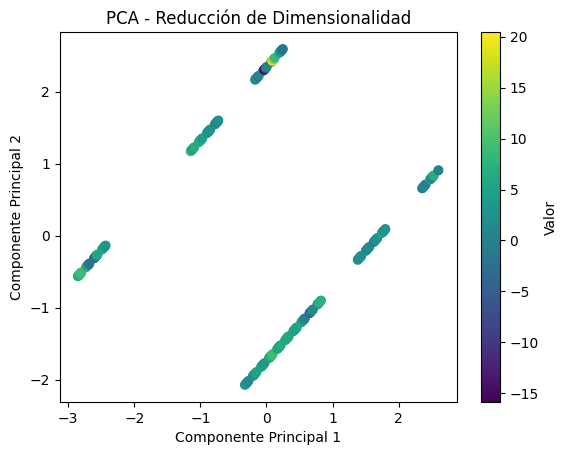

Varianza explicada por los componentes principales: [0.50440301 0.49543953]


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas para PCA
X_pca = df_encoded[['Año', 'fecha_num', 'color_blue', 'color_red']]

# Normalizar los datos
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Aplicar PCA
pca = PCA(n_components=2)  # Reducir a 2 componentes principales
X_pca_result = pca.fit_transform(X_scaled)

# Visualizar los resultados en un gráfico 2D
plt.scatter(X_pca_result[:, 0], X_pca_result[:, 1], c=df_encoded['Valor'], cmap='viridis')
plt.colorbar(label='Valor')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA - Reducción de Dimensionalidad')
plt.show()

# Explicar la varianza de los componentes principales
print("Varianza explicada por los componentes principales:", pca.explained_variance_ratio_)



Esto significa que:

- El **primer componente principal** (Componente 1) explica aproximadamente el **50.44%** de la varianza total en los datos.
- El **segundo componente principal** (Componente 2) explica aproximadamente el **49.54%** de la varianza total en los datos.

### Interpretación:
- **Componente 1** captura más de la mitad de la variabilidad de los datos, lo que indica que este componente es el más significativo en términos de la cantidad de información que retiene.
- **Componente 2** también captura una cantidad significativa de información, aunque ligeramente menor que el primero.

### ¿Por qué es importante la varianza explicada?
La **varianza explicada** te dice qué tan bien los nuevos componentes (resultantes de PCA) representan los datos originales.

Cuanto mayor sea la varianza explicada por los componentes seleccionados, más información de los datos originales se conserva, y se pierde menos detalle al reducir la dimensionalidad.

### En este caso:
Los dos primeros componentes principales explican el **99.99%** de la variabilidad de los datos. Esto sugiere que puedes reducir de manera efectiva las dimensiones del conjunto de datos a solo dos dimensiones, sin perder mucha información, lo que facilita la visualización y el análisis posterior.

### Resumen:
- **Componente Principal 1 (50.44%)**: Es el componente más importante, pues captura más de la mitad de la variabilidad de los datos.
- **Componente Principal 2 (49.54%)**: También es significativo, pero complementa al primero para lograr una representación completa de los datos.


         fecha  mensual  anual  anio  mes color
0   2011-01-01      0.3    2.7  2011    1   red
1   2011-02-01      0.2    2.7  2011    2   red
2   2011-03-01      0.8    3.4  2011    3   red
3   2011-04-01      0.3    3.2  2011    4   red
4   2011-05-01      0.4    3.3  2011    5   red
..         ...      ...    ...   ...  ...   ...
165 2024-10-01      1.0    4.7  2024   10  blue
166 2024-11-01      0.2    4.2  2024   11  blue
167 2024-12-01     -0.2    4.5  2024   12  blue
168 2025-01-01      1.1    4.9  2025    1  blue
169 2025-02-01      0.4    4.7  2025    2  blue

[170 rows x 6 columns]


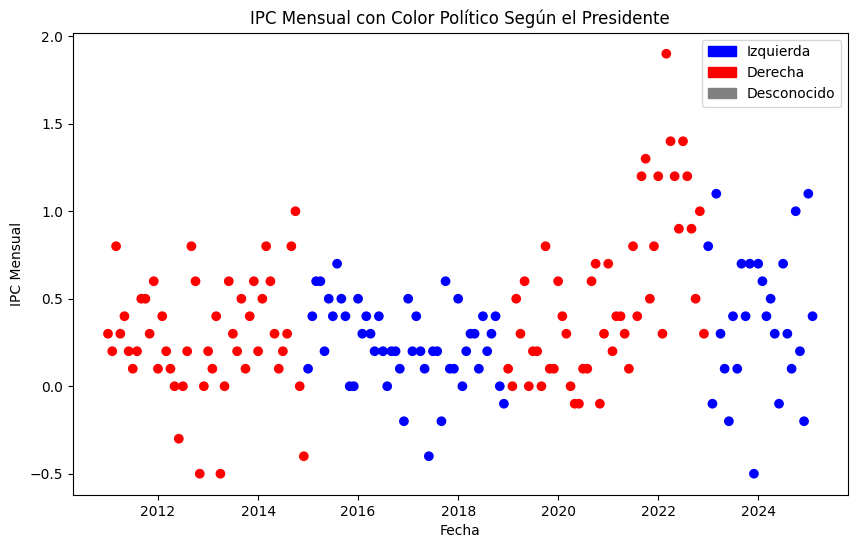

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Convertir las fechas a tipo datetime
df_ipc['fecha'] = pd.to_datetime(df_ipc['fecha'])

# Crear el DataFrame df_eventos
df_eventos = pd.DataFrame(data_eventos)

# Función para asignar el color político basado en la fecha
def asignar_color_politico(fecha):
    # Filtrar los presidentes que gobernaron en la fecha dada
    evento_actual = df_eventos[(df_eventos['inicio_evento'] <= fecha.year) &
                               (df_eventos['termino_evento'] >= fecha.year)]

    if not evento_actual.empty:
        # Si se encuentra un evento, se retorna el color asociado
        return evento_actual['color'].iloc[0]
    else:
        # Si no se encuentra un evento en ese periodo, asignar color 'gray'
        return 'gray'

# Aplicar la función al DataFrame df_ipc
df_ipc['color'] = df_ipc['fecha'].apply(asignar_color_politico)

# Ver los resultados
print(df_ipc)

# Graficar los datos de IPC con colores basados en el color político
plt.figure(figsize=(10, 6))
plt.scatter(df_ipc['fecha'], df_ipc['mensual'], c=df_ipc['color'], label="IPC Mensual")
plt.xlabel('Fecha')
plt.ylabel('IPC Mensual')
plt.title('IPC Mensual con Color Político Según el Presidente')

# Mostrar la leyenda
import matplotlib.patches as mpatches
legend_labels = [mpatches.Patch(color='blue', label='Izquierda'),
                 mpatches.Patch(color='red', label='Derecha'),
                 mpatches.Patch(color='gray', label='Desconocido')]
plt.legend(handles=legend_labels)

plt.show()


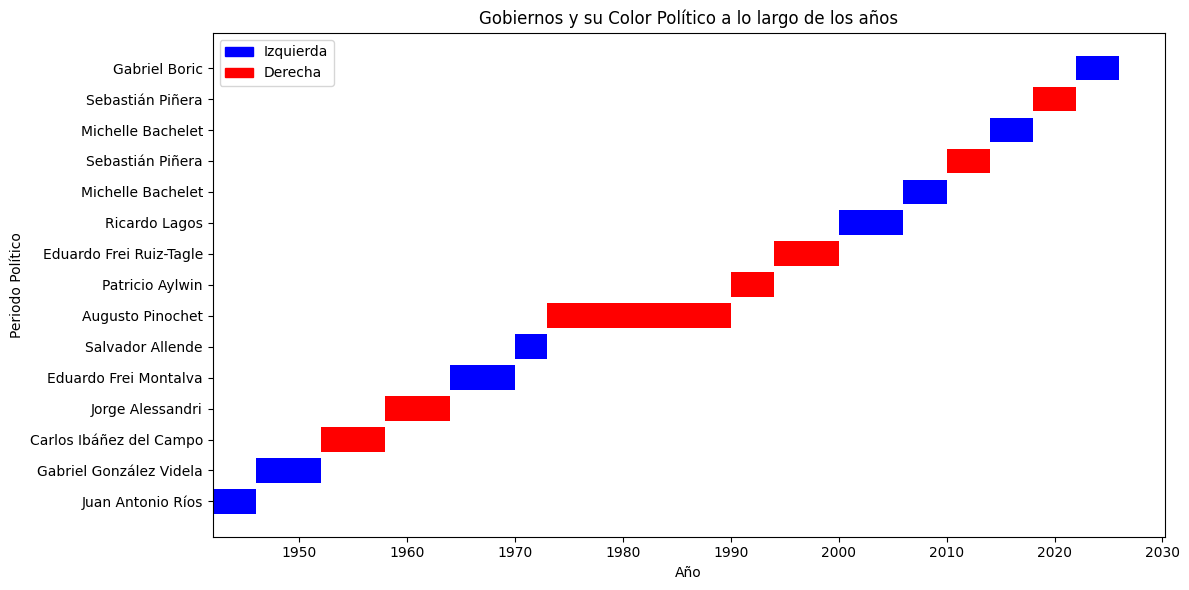

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# Crear gráfico de barras donde cada barra tiene un color según el periodo político
plt.figure(figsize=(12, 6))

# Colorear las barras según el color político en el periodo
for idx, (inicio, fin, color) in enumerate(zip(df_eventos['inicio_evento'], df_eventos['termino_evento'], df_eventos['color'])):
    plt.barh(y=[idx], width=[fin - inicio], left=[inicio], color=color, height=0.8)

# Etiquetas y título
plt.xlabel('Año')
plt.ylabel('Periodo Político')
plt.title('Gobiernos y su Color Político a lo largo de los años')

# Ajustar el eje Y para que sea más fácil de leer
plt.yticks(range(len(df_eventos)), df_eventos['evento'])

# Mostrar leyenda
legend_labels = [mpatches.Patch(color='blue', label='Izquierda'),
                 mpatches.Patch(color='red', label='Derecha')]
plt.legend(handles=legend_labels)

plt.tight_layout()
plt.show()


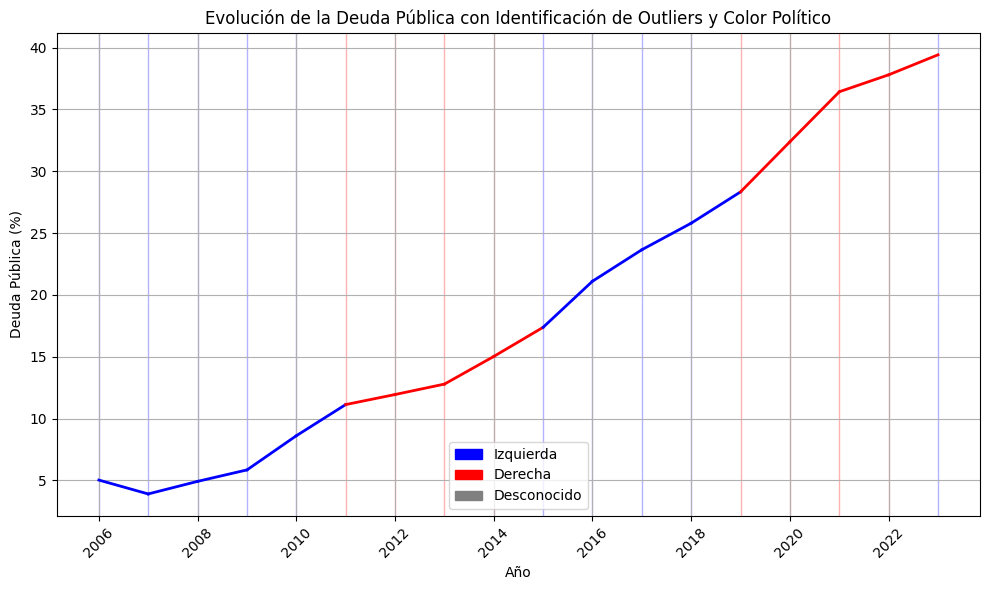

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Suponiendo que ya tienes el DataFrame df_deuda_publica_pib y df_eventos definidos
# Primero, aseguramos que 'Periodo' esté en formato datetime en ambos DataFrames
df_deuda_publica_pib['Periodo'] = pd.to_datetime(df_deuda_publica_pib['Periodo'])

# Función para asignar el color político según la fecha
def asignar_color_politico(fecha):
    evento_actual = df_eventos[(df_eventos['inicio_evento'] <= fecha.year) &
                               (df_eventos['termino_evento'] >= fecha.year)]

    if not evento_actual.empty:
        return evento_actual['color'].iloc[0]
    else:
        return 'gray'

# Aplicar la función al DataFrame df_deuda_publica_pib
df_deuda_publica_pib['color'] = df_deuda_publica_pib['Periodo'].apply(asignar_color_politico)

# Calcular la tasa de crecimiento
df_deuda_publica_pib['tasa_crecimiento_deuda_publica'] = df_deuda_publica_pib['deuda_publica'].pct_change() * 100
df_deuda_publica_pib['tasa_crecimiento_deuda_bruta'] = df_deuda_publica_pib['deuda_bruta_banco_central'].pct_change() * 100

# Identificar outliers utilizando el rango intercuartílico
Q1 = df_deuda_publica_pib['deuda_publica'].quantile(0.25)
Q3 = df_deuda_publica_pib['deuda_publica'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_deuda_publica_pib[(df_deuda_publica_pib['deuda_publica'] > Q3 + 1.5 * IQR) |
                                 (df_deuda_publica_pib['deuda_publica'] < Q1 - 1.5 * IQR)]

# Graficar la deuda pública y los outliers, con color según el color político
plt.figure(figsize=(10, 6))

# Graficar la deuda pública con el color político y un ancho mayor
for i in range(len(df_deuda_publica_pib) - 1):  # Recorremos los períodos
    # Graficamos la línea entre los puntos adyacentes, con el color político del período actual
    plt.plot(df_deuda_publica_pib['Periodo'].iloc[i:i+2],
             df_deuda_publica_pib['deuda_publica'].iloc[i:i+2],
             color=df_deuda_publica_pib['color'].iloc[i], linewidth=2)

# Graficar los outliers
plt.scatter(outliers['Periodo'], outliers['deuda_publica'], color='red', label='Outliers')

# Graficar las barras con el color político (no es necesario para las líneas ya coloreadas)
for i in range(len(df_deuda_publica_pib)):
    plt.axvspan(df_deuda_publica_pib['Periodo'].iloc[i], df_deuda_publica_pib['Periodo'].iloc[i],
                color=df_deuda_publica_pib['color'].iloc[i], alpha=0.3)

plt.xlabel('Año')
plt.ylabel('Deuda Pública (%)')
plt.title('Evolución de la Deuda Pública con Identificación de Outliers y Color Político')

# Mostrar leyenda
legend_labels = [mpatches.Patch(color='blue', label='Izquierda'),
                 mpatches.Patch(color='red', label='Derecha'),
                 mpatches.Patch(color='gray', label='Desconocido')]
plt.legend(handles=legend_labels)

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


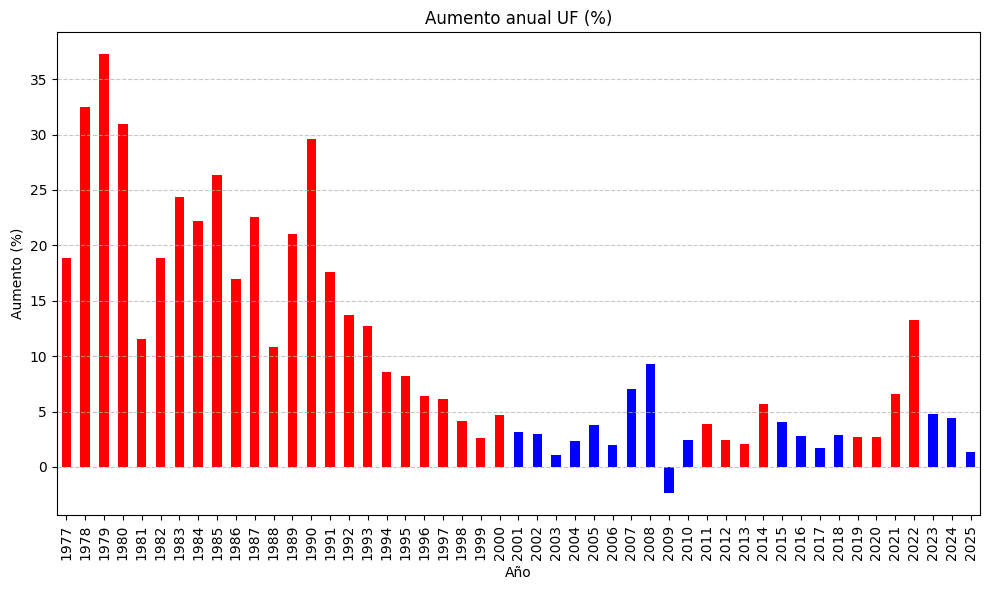

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Suponiendo que ya tienes el DataFrame uf_por_anio y df_eventos definidos

# Función para asignar el color político según el año
def asignar_color_politico(fecha):
    evento_actual = df_eventos[(df_eventos['inicio_evento'] <= fecha) &
                               (df_eventos['termino_evento'] >= fecha)]

    if not evento_actual.empty:
        return evento_actual['color'].iloc[0]
    else:
        return 'gray'

# Asumimos que el índice de uf_por_anio corresponde a los años
uf_por_anio['color'] = uf_por_anio.index.to_series().apply(asignar_color_politico)

# Crear el gráfico de barras con colores asignados
plt.figure(figsize=(10,6))
bars = uf_por_anio['crecimiento_%'].plot(kind='bar', color=uf_por_anio['color'])

# Añadir título y etiquetas
plt.title('Aumento anual UF (%)')
plt.xlabel('Año')
plt.ylabel('Aumento (%)')

# Configuración de la cuadrícula
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Asegurar que el diseño esté bien ajustado
plt.tight_layout()

# Mostrar el gráfico
plt.show()


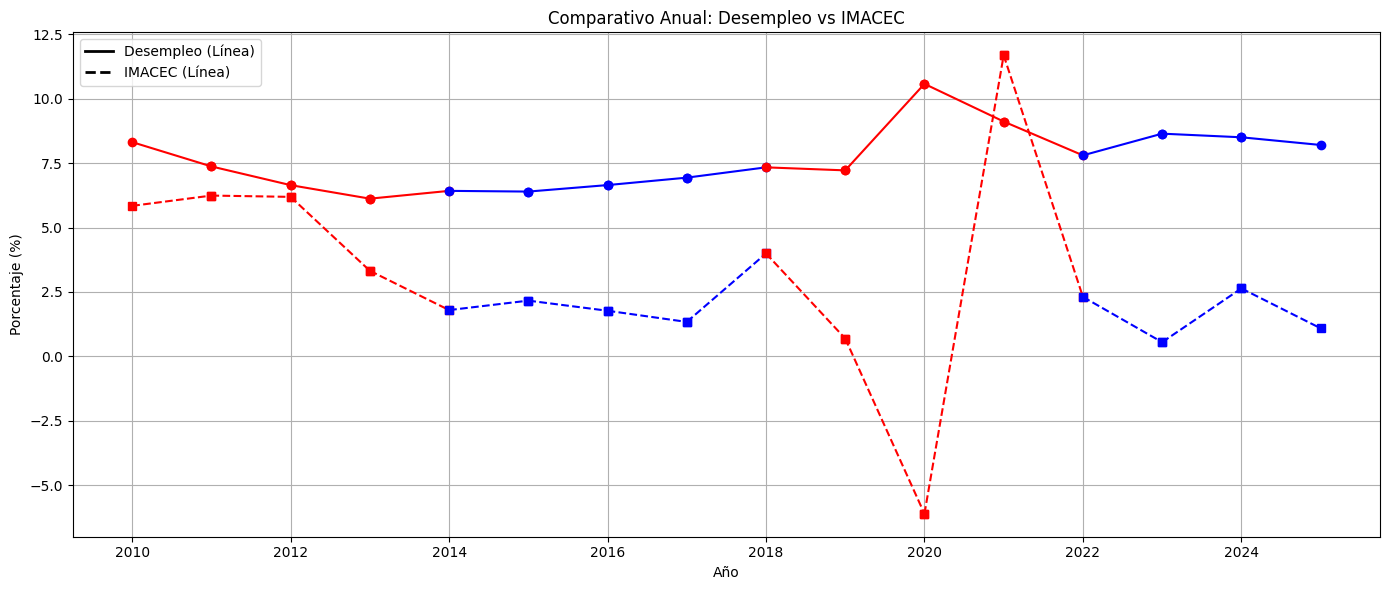

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D # Import Line2D from matplotlib.lines
import matplotlib.patches as mpatches

# Asegurar formato datetime
df_desempleo['Mes'] = pd.to_datetime(df_desempleo['Mes'])
df_imacec['Mes'] = pd.to_datetime(df_imacec['Mes'])

# Agregar columna Año
df_desempleo['Año'] = df_desempleo['Mes'].dt.year
df_imacec['Año'] = df_imacec['Mes'].dt.year

# Promedios anuales
desempleo_anual = df_desempleo.groupby('Año')['Valor'].mean().reset_index(name='Desempleo')
imacec_anual = df_imacec.groupby('Año')['Valor'].mean().reset_index(name='IMACEC')

# Unir ambos DataFrames por año
df_comparativo = pd.merge(desempleo_anual, imacec_anual, on='Año')

# Función para asignar el color político según el año
def asignar_color_politico(fecha):
    evento_actual = df_eventos[(df_eventos['inicio_evento'] <= fecha) &
                               (df_eventos['termino_evento'] >= fecha)]

    if not evento_actual.empty:
        return evento_actual['color'].iloc[0]
    else:
        return 'gray'

# Asignar colores políticos a los años
df_comparativo['color'] = df_comparativo['Año'].apply(asignar_color_politico)

# Graficar
plt.figure(figsize=(14, 6))

# Graficar la línea de Desempleo con el color asignado
for i in range(1, len(df_comparativo)):
    plt.plot(df_comparativo['Año'].iloc[i-1:i+1], df_comparativo['Desempleo'].iloc[i-1:i+1],
             marker='o', color=df_comparativo['color'].iloc[i], linestyle='-', label='Desempleo' if i == 1 else "")

# Graficar la línea de IMACEC con el color asignado
for i in range(1, len(df_comparativo)):
    plt.plot(df_comparativo['Año'].iloc[i-1:i+1], df_comparativo['IMACEC'].iloc[i-1:i+1],
             marker='s', color=df_comparativo['color'].iloc[i], linestyle='--', label='IMACEC' if i == 1 else "")

# Título y etiquetas
plt.title('Comparativo Anual: Desempleo vs IMACEC')
plt.xlabel('Año')
plt.ylabel('Porcentaje (%)')

# Leyenda con las etiquetas de Desempleo e IMACEC
plt.legend(loc='upper left')

# Leyenda con color político
legend_labels = [mpatches.Patch(color='blue', label='Izquierda'),
                 mpatches.Patch(color='red', label='Derecha'),
                 mpatches.Patch(color='gray', label='Desconocido')]

# Leyenda de líneas y marcadores
line_legend = [Line2D([0], [0], color='black', lw=2, label='Desempleo (Línea)'), # Use Line2D from matplotlib.lines
               Line2D([0], [0], color='black', lw=2, linestyle='--', label='IMACEC (Línea)')] # Use Line2D from matplotlib.lines


# Agregar leyenda
plt.legend(handles=legend_labels, loc='lower left', title='Color Político')
plt.legend(handles=line_legend, loc='upper left')

# Configurar la cuadrícula y ajustar el diseño
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def listar_dataframes():
    return [name for name, obj in globals().items() if isinstance(obj, pd.DataFrame)]

# Llamar a la función para obtener la lista de DataFrames
dataframes = listar_dataframes()
print(dataframes)

['df', '_4', '_5', '_8', 'uf_por_anio', 'enero_1', 'dic_31', 'correlation', 'df_ipc', '_16', '_18', '_19', 'df_mensual', 'enero', 'diciembre', 'df_anual', 'df_pivot', '_28', 'df_imacec', '_30', '_31', 'imacec_anual', 'df_desempleo', '_34', '_35', 'desempleo_anual', 'df_comparativo', 'df_pib', '_39', 'pib_anual', 'df_deuda_publica_pib', '_42', 'outliers', 'df_todos_anos', 'df_cartera', '_47', 'df_filtrado', 'df_todos_anos_numericos', 'correlation_matrix', 'df_eventos', '_56', 'X', '_63', 'df_encoded', '_72', 'coef_df', 'feature_importance_df', 'X_pca']
